In [2]:
import pandas as pd
import numpy as np
import datetime
from epiweeks import Week
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from datetime import timedelta
from matplotlib.lines import Line2D
import math

import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter


import warnings
warnings.filterwarnings('ignore')

In [2]:
os.mkdir('figs')

# Fig S1 - submission format sensitivity analysis

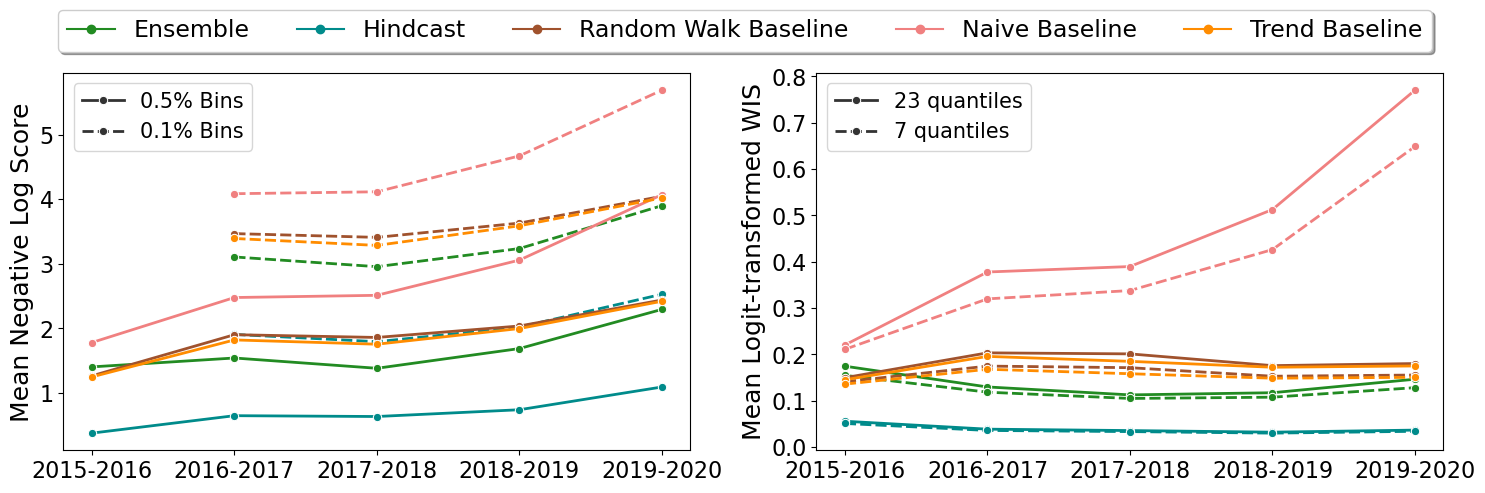

In [4]:
ls = pd.read_parquet('submission format sensitivity analysis/scores/ls_combined.parquet').sort_values(by='season')

ls['Model'] = ls['Model'].apply(lambda x: '0.5% Bins' if x=='Bigger Bins' else '0.1% Bins')

fig,ax = plt.subplots(1,2,figsize=(15,5))
palette = {
    'Hindcast': 'darkcyan',
    'Ensemble': 'forestgreen',
    'Random Walk Baseline': 'sienna',
    'Naive Baseline': 'lightcoral',
    'Trend Baseline': 'darkorange'
}

plt.subplot(1,2,1)

flu_ensemble_h = ls[['season', 'ls_hindcast','Model']].copy()
flu_ensemble_h['model'] = 'Hindcast'
flu_ensemble_f = ls[['season', 'ls','Model']].copy()
flu_ensemble_f['model'] = 'Ensemble'

flu_baseline_b = ls[['season', 'ls_lbaseline','Model']].copy().dropna()
flu_baseline_b['model'] = 'Random Walk Baseline'

flu_ensemble_n = ls[['season', 'ls_naive','Model']].copy()
flu_ensemble_n['model'] = 'Naive Baseline'

flu_ensemble_ets = ls[['season', 'ls_ETS','Model']].copy()
flu_ensemble_ets['model'] = 'Trend Baseline'

# Rename columns to match
flu_ensemble_h = flu_ensemble_h.rename(columns={'ls_hindcast': 'ls'})
flu_ensemble_n = flu_ensemble_n.rename(columns={'ls_naive': 'ls'})
flu_baseline_b = flu_baseline_b.rename(columns={'ls_lbaseline': 'ls'})
flu_ensemble_ets = flu_ensemble_ets.rename(columns={'ls_ETS': 'ls'})


# Combine all data
all_data = pd.concat([flu_ensemble_h, flu_ensemble_f], ignore_index=True)
all_data = pd.concat([all_data, flu_baseline_b], ignore_index=True)
all_data = pd.concat([all_data, flu_ensemble_n], ignore_index=True)
all_data = pd.concat([all_data, flu_ensemble_ets], ignore_index=True)

all_data['ls'] = -all_data['ls']

sns.lineplot(x='season', y='ls', hue='model', data=all_data,estimator='mean', style='Model', 
              errorbar=None,palette=palette,
            linewidth=2,markers='o')  # dodge controls separation

plt.xlabel('')
plt.ylabel('Mean Negative Log Score', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [7,8] 
ax[0].legend([handles[i] for i in order], [labels[i] for i in order],fontsize=15)


plt.subplot(1,2,2)

logwis = pd.read_parquet('submission format sensitivity analysis/scores/logit_wis_combined.parquet').sort_values(by='season')
logwis = logwis[logwis.Model.isin(['7 quantiles  with Interpolation', '23 quantiles  with Interpolation'])]
logwis['Model'] = logwis['Model'].apply(lambda x: x[0:-20])

flu_ensemble_h = logwis[['season', 'logit_wis_hindcast','Model']].copy()
flu_ensemble_h['model'] = 'Hindcast'
flu_ensemble_f = logwis[['season', 'logit_wis','Model']].copy()
flu_ensemble_f['model'] = 'Ensemble'

flu_baseline_b = logwis[['season', 'logit_wis_lbaseline','Model']].copy().dropna()
flu_baseline_b['model'] = 'Random Walk Baseline'

flu_ensemble_n = logwis[['season', 'logit_wis_naive','Model']].copy()
flu_ensemble_n['model'] = 'Naive Baseline'

flu_ensemble_ets = logwis[['season', 'logit_wis_ets_baseline','Model']].copy()
flu_ensemble_ets['model'] = 'Trend Baseline'

# Rename columns to match
flu_ensemble_h = flu_ensemble_h.rename(columns={'logit_wis_hindcast': 'logit_wis'})
flu_ensemble_n = flu_ensemble_n.rename(columns={'logit_wis_naive': 'logit_wis'})
flu_baseline_b = flu_baseline_b.rename(columns={'logit_wis_lbaseline': 'logit_wis'})
flu_ensemble_ets = flu_ensemble_ets.rename(columns={'logit_wis_ets_baseline': 'logit_wis'})


# Combine all data
all_data = pd.concat([flu_ensemble_h, flu_ensemble_f], ignore_index=True)
all_data = pd.concat([all_data, flu_baseline_b], ignore_index=True)
all_data = pd.concat([all_data, flu_ensemble_n], ignore_index=True)
all_data = pd.concat([all_data, flu_ensemble_ets], ignore_index=True)

sns.lineplot(x='season', y='logit_wis', hue='model', data=all_data,estimator='mean', style='Model', 
              errorbar=None,palette=palette,
            linewidth=2,markers='o')  # dodge controls separation

handles, labels = plt.gca().get_legend_handles_labels() 
  
order = [7,8] 
ax[1].legend([handles[i] for i in order], [labels[i] for i in order],fontsize=15,)

plt.xlabel('')
plt.ylabel('Mean Logit-transformed WIS', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

color_handles = [
    Line2D([0], [0], color='forestgreen', marker='o', markersize=6, label='Ensemble'),
    Line2D([0], [0], color='darkcyan', marker='o', markersize=6, label='Hindcast'),
    Line2D([0], [0], color='sienna', marker='o', markersize=6, label='Random Walk Baseline'),
    Line2D([0], [0], color='lightcoral', marker='o', markersize=6, label='Naive Baseline'),
    Line2D([0], [0], color='darkorange', marker='o', markersize=6, label='Trend Baseline'),
]



# Combine legends
all_handles = color_handles 

# Add legend above subplots
fig.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1), 
           ncol=5, fontsize=17, fancybox=True, shadow=True  )

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Make room for the legend


plt.savefig('figs/figS1-bin_vs_quantile_score.pdf')

plt.show()

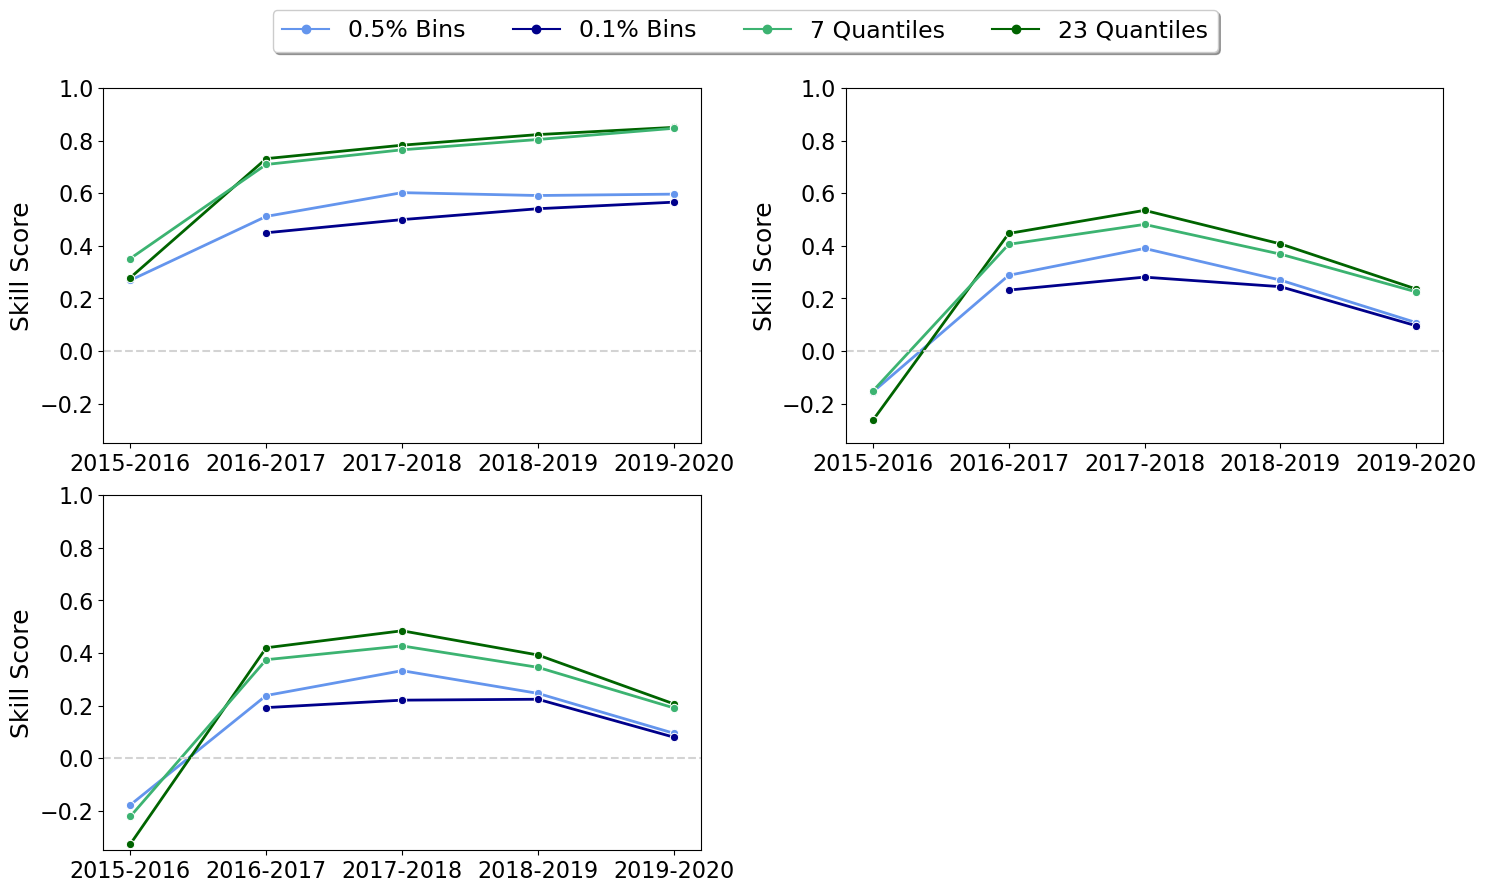

In [5]:
palettebins=['cornflowerblue', 'darkblue']
palettequants=['darkgreen','mediumseagreen']

fig,ax = plt.subplots(2,2,figsize=(15,9),)

plt.subplot(2,2,2)

logwis = pd.read_parquet('submission format sensitivity analysis/scores/logit_wis_combined.parquet')
logwis = logwis[logwis.Model.isin(['7 quantiles  with Interpolation', '23 quantiles  with Interpolation'])]
logwis['Model'] = logwis['Model'].apply(lambda x: x[0:-20])
logwis = logwis.sort_values(by='Model',ascending=False)

ls = pd.read_parquet('submission format sensitivity analysis/scores/ls_combined.parquet')
   
flu_LS_filtered = ls.copy()

df = flu_LS_filtered.copy()


df = df.groupby(['Model','season'])['ls', 'ls_lbaseline', 'ls_hindcast'].mean().reset_index()

df['ss'] = (df['ls'] - df['ls_lbaseline']) / (df['ls_hindcast'] - df['ls_lbaseline'])

vals = df.groupby(['Model','season'])['ss'].mean().reset_index()

sns.lineplot(x='season', y='ss', data=vals, hue='Model', palette=palettebins,
            style='Model', markers=['o'], dashes=False, linewidth=2,legend=False)

# plot quantile results
flu_LS_filtered = logwis.copy()

df = flu_LS_filtered.copy()


df = df.groupby(['Model','season'])['logit_wis', 'logit_wis_lbaseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_lbaseline']) / (df['logit_wis_hindcast'] - df['logit_wis_lbaseline'])

vals = df.groupby(['Model','season'])['ss'].mean().reset_index()

sns.lineplot(x='season', y='ss', data=vals, hue='Model', palette=palettequants,
            style='Model', markers=['o'], dashes=False, linewidth=2,legend=False)

plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.35,1])
plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('', fontsize=18)

plt.subplot(2,2,1)

logwis = pd.read_parquet('submission format sensitivity analysis/scores/logit_wis_combined.parquet')
logwis = logwis[logwis.Model.isin(['7 quantiles  with Interpolation', '23 quantiles  with Interpolation'])]
logwis['Model'] = logwis['Model'].apply(lambda x: x[0:-20])


ls = pd.read_parquet('submission format sensitivity analysis/scores/ls_combined.parquet')
  
flu_LS_filtered = ls.copy()

df = flu_LS_filtered.copy()


df = df.groupby(['Model','season'])['ls', 'ls_naive', 'ls_hindcast'].mean().reset_index()

df['ss'] = (df['ls'] - df['ls_naive']) / (df['ls_hindcast'] - df['ls_naive'])

vals = df.groupby(['Model','season'])['ss'].mean().reset_index()

sns.lineplot(x='season', y='ss', data=vals, hue='Model', palette=palettebins,
            style='Model', markers=['o'], dashes=False, linewidth=2,legend=False)

# plot quantile results
flu_LS_filtered = logwis.copy()

df = flu_LS_filtered.copy()


df = df.groupby(['Model','season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])

vals = df.groupby(['Model','season'])['ss'].mean().reset_index()

sns.lineplot(x='season', y='ss', data=vals, hue='Model', palette=palettequants,
            style='Model', markers=['o'], dashes=False, linewidth=2,legend=False)


plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.35,1])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('', fontsize=18)


plt.subplot(2,2,3)

logwis = pd.read_parquet('submission format sensitivity analysis/scores/logit_wis_combined.parquet')
logwis = logwis[logwis.Model.isin(['7 quantiles  with Interpolation', '23 quantiles  with Interpolation'])]
logwis['Model'] = logwis['Model'].apply(lambda x: x[0:-20])
logwis = logwis.sort_values(by='Model',ascending=False)

ls = pd.read_parquet('submission format sensitivity analysis/scores/ls_combined.parquet')

df = ls.copy()


df = df.groupby(['Model','season'])['ls', 'ls_ETS', 'ls_hindcast'].mean().reset_index()

df['ss'] = (df['ls'] - df['ls_ETS']) / (df['ls_hindcast'] - df['ls_ETS'])

vals = df.groupby(['Model','season'])['ss'].mean().reset_index()

sns.lineplot(x='season', y='ss', data=vals, hue='Model', palette=palettebins,
            style='Model', markers=['o'], dashes=False, linewidth=2,legend=False)

# plot quantile results
flu_LS_filtered = logwis.copy()

df = flu_LS_filtered.copy()


df = df.groupby(['Model','season'])['logit_wis', 'logit_wis_ets_baseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_ets_baseline'])

vals = df.groupby(['Model','season'])['ss'].mean().reset_index()

sns.lineplot(x='season', y='ss', data=vals, hue='Model', palette=palettequants,
            style='Model', markers=['o'], dashes=False, linewidth=2,legend=False)

plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.35,1])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('', fontsize=18)

color_handles = [
    Line2D([0], [0], color='cornflowerblue', marker='o', markersize=6, label='0.5% Bins'),
    Line2D([0], [0], color='darkblue', marker='o', markersize=6, label='0.1% Bins'),
    Line2D([0], [0], color='mediumseagreen', marker='o', markersize=6, label='7 Quantiles'),
    Line2D([0], [0], color='darkgreen', marker='o', markersize=6, label='23 Quantiles'),   
]

# Combine legends
all_handles = color_handles 

# Add legend above subplots
fig.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1), 
           ncol=4, fontsize=17, fancybox=True, shadow=True  )

fig.delaxes(ax[1,1])
plt.tight_layout()

plt.subplots_adjust(top=0.9)  # Make room for the legend

plt.savefig('figs/figS1-skillscore_bin_vs_quantile.pdf')
plt.show()

# Fig S2 - ensemble WIS over time

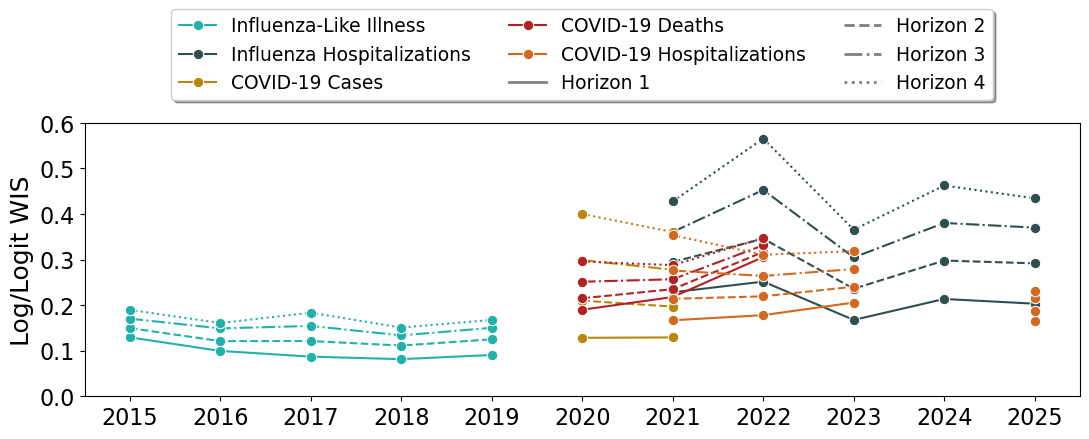

In [8]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble.copy()
df = df.groupby(['team','season','horizon'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()

df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].logit_wis,ax=ax,color='lightseagreen',
        alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
        label=f'Influenza-Like Illness')

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    
    df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].log_wis,ax=ax,color='darkslategrey',
            alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
    
    i+=1

    
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]

        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season','horizon'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    
       
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].log_wis,ax=ax,color=colors,
                alpha=1,linestyle=line_styles[i % len(line_styles)],marker='.',markersize=15,
                label=f'{label}')
        i+=1
    j+=1
    

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,4,8,12,16] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',  linewidth=2, label='Horizon 1'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Horizon 2'),
    Line2D([0], [0], color='gray', linestyle='-.', linewidth=2, label='Horizon 3'),
    Line2D([0], [0], color='gray', linestyle=':',  linewidth=2, label='Horizon 4')
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]


    

ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center',          
    bbox_to_anchor=(0.5, 1.45), 
    ncol=3,                     
    fancybox=True,              
 shadow=True               
)

plt.ylim([0,.6])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Log/Logit WIS', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/figS2-logwis_ensemble.pdf')
plt.show()

# Fig S3 - skill score by horizon

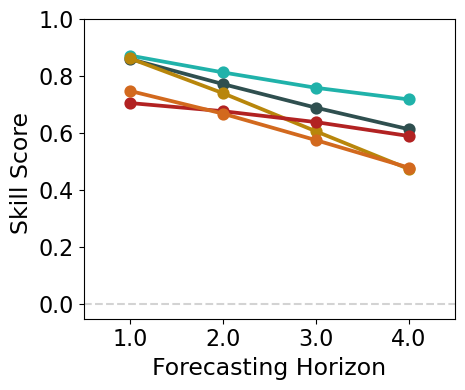

In [10]:
## Make skill score by horizon plot by disease outcome - average across all seasons

fig,ax = plt.subplots(1,1,figsize=(4.75,4))

# Flu ILI
ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
flu_ensemble['horizon'] = flu_ensemble['horizon'].astype(float)
    
flu_ensemble['horizon'] = flu_ensemble['horizon']+2
    
df =  flu_ensemble.groupby(['team','horizon'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])

vals = df.groupby(['horizon'])['ss'].mean().reset_index()

g = sns.pointplot(x='horizon', y='ss', data=vals,label='Influenza-Like Illness',color='lightseagreen',legend=False)


# Flu hosp
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
   
flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
(flu_WIS['team'].isin(['Flusight-ensemble', 'FluSight-ensemble', ]))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

df = flu_WIS_filtered.groupby(['team','horizon'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
vals = df.groupby(['team' ,'horizon'])['ss'].mean().reset_index()

g = sns.pointplot(x='horizon', y='ss', data=vals,label='Influenza Hospitalizations',color='darkslategrey',legend=False)


# COVID
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)


teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
for target in covid_WIS.outcome.unique():

    covid_WIS_filtered = covid_WIS[ (covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) & (covid_WIS.team.isin(teams))&\
                                      (~covid_WIS.location.isin(['60']))].copy()

    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1
    
    if target=='hosp':
        colors = 'chocolate'
        label = 'Hospitalizations'
    elif target=='death':
        colors = 'firebrick'
        label='Deaths'
    elif target=='case':
        colors = 'darkgoldenrod'
        label='Cases'

    df = covid_WIS_filtered[(covid_WIS_filtered.outcome==target)]

    df = df.groupby(['horizon'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
    vals = df.groupby(['horizon'])['ss'].mean().reset_index()

    g = sns.pointplot(x='horizon', y='ss', data=vals,label=f'COVID-19 {label}',color=colors,legend=False)

plt.ylim([-.05,1])

for patch in ax.patches:
    r, gr, b, a = patch.get_facecolor()
    patch.set_facecolor((r, gr, b, .75))
    

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.axhline(y=0,color='lightgray',linestyle='--')
plt.xlabel('Forecasting Horizon', fontsize=17)
plt.ylabel('Skill Score ', fontsize=17)

plt.tight_layout()

plt.savefig('figs/figS3-SS_horizon_naive.pdf')

plt.show()

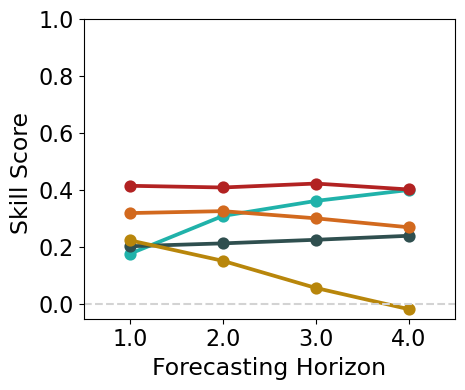

In [11]:
## Make skill score by horizon plot by disease outcome - average across all seasons

fig,ax = plt.subplots(1,1,figsize=(4.75,4))

# Flu ILI
ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
flu_ensemble['horizon'] = flu_ensemble['horizon'].astype(float)
 
flu_ensemble['horizon'] = flu_ensemble['horizon']+2
   
df =  flu_ensemble.groupby(['team','horizon'])['logit_wis', 'logit_wis_logit_baseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_logit_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_logit_baseline'])

vals = df.groupby(['team','horizon'])['ss'].mean().reset_index()

g = sns.pointplot(x='horizon', y='ss', data=vals,label='FluSight ILI',color='lightseagreen',legend=False)


# Flu hosp
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))

flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
(flu_WIS['team'].isin(['Flusight-ensemble', 'FluSight-ensemble', ]))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()
flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

df = flu_WIS_filtered.groupby(['team','horizon'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])
vals = df.groupby(['team' ,'horizon'])['ss'].mean().reset_index()

g = sns.pointplot(x='horizon', y='ss', data=vals,label='FluSight Hospitalizations',color='darkslategrey',legend=False)


# COVID
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
for target in covid_WIS.outcome.unique():

    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) & (covid_WIS.team.isin(teams))&\
                                      (~covid_WIS.location.isin(['60']))].copy()
    
    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1
    
    if target=='hosp':
        colors = 'chocolate'
        label = 'Hospitalizations'
    elif target=='death':
        colors = 'firebrick'
        label='Deaths'
    elif target=='case':
        colors = 'darkgoldenrod'
        label='Cases'

    df = covid_WIS_filtered[(covid_WIS_filtered.outcome==target)]
    df = df.groupby(['horizon'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])
    vals = df.groupby(['horizon'])['ss'].mean().reset_index()

    g = sns.pointplot(x='horizon', y='ss', data=vals,label=f'COVID {label}',color=colors,legend=False)

plt.ylim([-.05,1])

for patch in ax.patches:
    r, gr, b, a = patch.get_facecolor()
    patch.set_facecolor((r, gr, b, .75))

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.axhline(y=0,color='lightgray',linestyle='--')
plt.xlabel('Forecasting Horizon', fontsize=17)
plt.ylabel('Skill Score ', fontsize=17)


plt.tight_layout()

plt.savefig('figs/figS3-SS_horizon_RW.pdf')

plt.show()

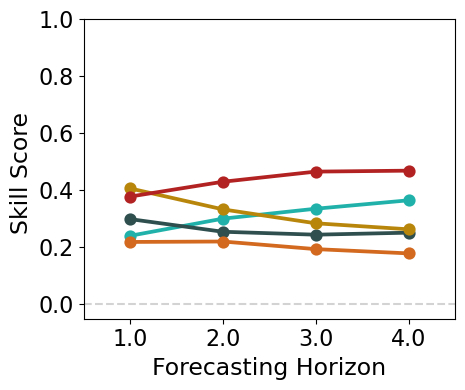

In [13]:
## Make skill score by horizon plot by disease outcome - average across all seasons
fig,ax = plt.subplots(1,1,figsize=(4.75,4))

# Flu ILI
ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
flu_ensemble['horizon'] = flu_ensemble['horizon'].astype(float)
flu_ensemble['horizon'] = flu_ensemble['horizon']+2
   
df =  flu_ensemble.groupby(['team','horizon'])['logit_wis', 'logit_wis_ets_baseline', 'logit_wis_hindcast'].mean().reset_index()
df['ss'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_ets_baseline'])
vals = df.groupby(['team','horizon'])['ss'].mean().reset_index()

g = sns.pointplot(x='horizon', y='ss', data=vals,label='FluSight ILI',color='lightseagreen',legend=False)


# Flu hosp
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))

        
flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
(flu_WIS['team'].isin(['Flusight-ensemble', 'FluSight-ensemble', ]))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

flu_WIS_filtered['horizon'] = flu_WIS_filtered['horizon']+1

df = flu_WIS_filtered.groupby(['team','horizon'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])
vals = df.groupby(['team' ,'horizon'])['ss'].mean().reset_index()

g = sns.pointplot(x='horizon', y='ss', data=vals,label='FluSight Hospitalizations',color='darkslategrey',legend=False)


# COVID
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
for target in covid_WIS.outcome.unique():

    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) & (covid_WIS.team.isin(teams))&\
                                      (~covid_WIS.location.isin(['60']))].copy()

    covid_WIS_filtered['horizon'] = covid_WIS_filtered['horizon']+1

    if target=='hosp':
        colors = 'chocolate'
        label = 'Hospitalizations'
    elif target=='death':
        colors = 'firebrick'
        label='Deaths'
    elif target=='case':
        colors = 'darkgoldenrod'
        label='Cases'

    df = covid_WIS_filtered[(covid_WIS_filtered.outcome==target)]
    df = df.groupby(['horizon'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])
    vals = df.groupby(['horizon'])['ss'].mean().reset_index()

    g = sns.pointplot(x='horizon', y='ss', data=vals,label=f'COVID {label}',color=colors,legend=False)

plt.ylim([-.05,1])

for patch in ax.patches:
    r, gr, b, a = patch.get_facecolor()
    patch.set_facecolor((r, gr, b, .75))

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.axhline(y=0,color='lightgray',linestyle='--')
plt.xlabel('Forecasting Horizon', fontsize=17)
plt.ylabel('Skill Score ', fontsize=17)


plt.tight_layout()

plt.savefig('figs/figS3-SS_horizon_trend.pdf')

plt.show()

# Fig S4 - impact of hindcast

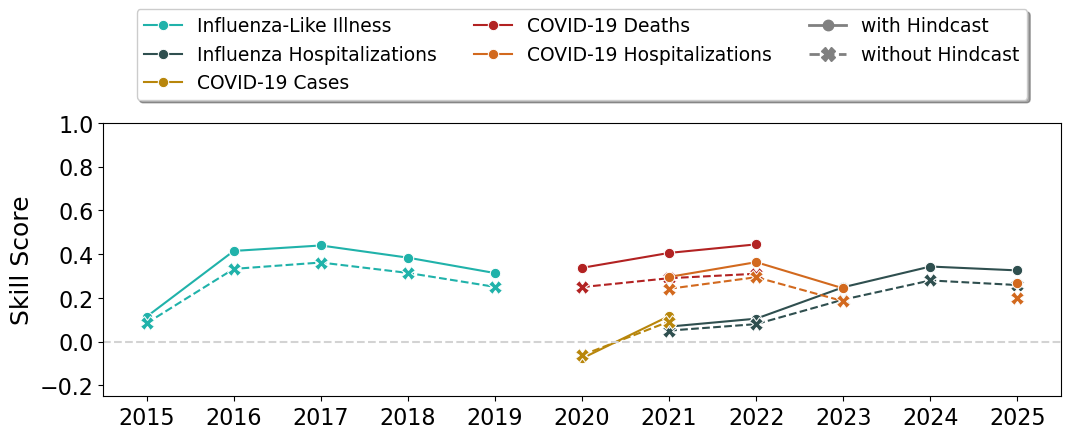

In [14]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))

df = flu_ensemble.copy()

df = df.groupby(['team','season'])['logit_wis', 'logit_wis_logit_baseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_logit_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_logit_baseline'])
df['relwis'] = (df['logit_wis'] - df['logit_wis_logit_baseline']) / (0 - df['logit_wis_logit_baseline'])

df['horizon'] = 0

vals = df.groupby(['season'])['ss'].mean()

df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='lightseagreen',
        alpha=1,linestyle='-',marker='.',markersize=15,
        label=f'Influenza-Like Illness')
    
    sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color='lightseagreen',
        alpha=1,linestyle='--',marker='X',markersize=10)

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    df = df.groupby(['team','season'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    
    df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])
    df['relwis'] = (df['log_wis'] - df['log_wis_lbaseline']) / (0 - df['log_wis_lbaseline'])
    df['horizon'] = 0
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='darkslategrey',
            alpha=1,linestyle='-',marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
        
        sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color='darkslategrey',
            alpha=1,linestyle='--',marker='X',markersize=10)

    i+=1
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]

        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season',])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])
        df['relwis'] = (df['log_wis'] - df['log_wis_lbaseline']) / (0 - df['log_wis_lbaseline'])
        df['horizon'] = 0
        
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color=colors,
                alpha=1,linestyle='-',marker='.',markersize=15,
                label=f'{label}')
            
            sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color=colors,
                alpha=1,linestyle='--',marker='X',markersize=10)

        i+=1
    j+=1

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,1,2,3,4] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',marker='.', markersize=15, linewidth=2, label='with Hindcast'),
    Line2D([0], [0], color='gray', linestyle='--',marker='X',markersize=10, linewidth=2, label='without Hindcast'),
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]

ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center',         
    bbox_to_anchor=(0.5, 1.45),  ncol=3, fancybox=True, shadow=True )

plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.25,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/figS4-SS_hindcast_comp_RW.pdf')
plt.show()

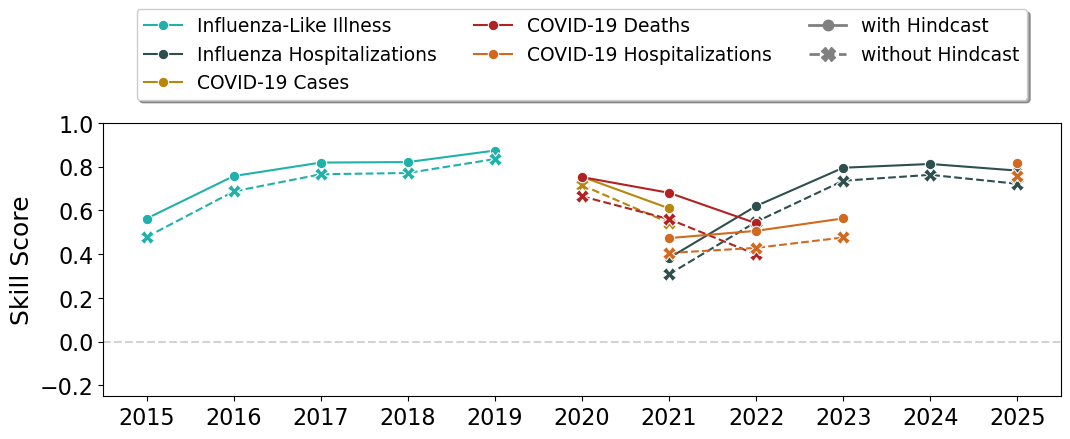

In [15]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble.copy()

df = df.groupby(['team','season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])
df['relwis'] = (df['logit_wis'] - df['logit_wis_naive']) / (0 - df['logit_wis_naive'])
df['horizon'] = 0

vals = df.groupby(['season'])['ss'].mean()

df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='lightseagreen',
        alpha=1,linestyle='-',marker='.',markersize=15,
        label=f'Influenza-Like Illness')
    
    sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color='lightseagreen',
        alpha=1,linestyle='--',marker='X',markersize=10)

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    
    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    
    df = df.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    
    df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
    df['relwis'] = (df['log_wis'] - df['log_wis_naive']) / (0 - df['log_wis_naive'])
    df['horizon'] = 0
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='darkslategrey',
            alpha=1,linestyle='-',marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
        
        sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color='darkslategrey',
            alpha=1,linestyle='--',marker='X',markersize=10)

    i+=1
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]
        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season',])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])
        df['relwis'] = (df['log_wis'] - df['log_wis_naive']) / (0 - df['log_wis_naive'])
        df['horizon'] = 0
        
        
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color=colors,
                alpha=1,linestyle='-',marker='.',markersize=15,
                label=f'{label}')
            
            sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color=colors,
                alpha=1,linestyle='--',marker='X',markersize=10)

        i+=1
    j+=1
    

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,1,2,3,4] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',marker='.', markersize=15, linewidth=2, label='with Hindcast'),
    Line2D([0], [0], color='gray', linestyle='--',marker='X',markersize=10, linewidth=2, label='without Hindcast'),
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]

ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center',bbox_to_anchor=(0.5, 1.45), ncol=3,fancybox=True, shadow=True )

plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.25,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/figS4-SS_hindcast_comp_naive.pdf')
plt.show()

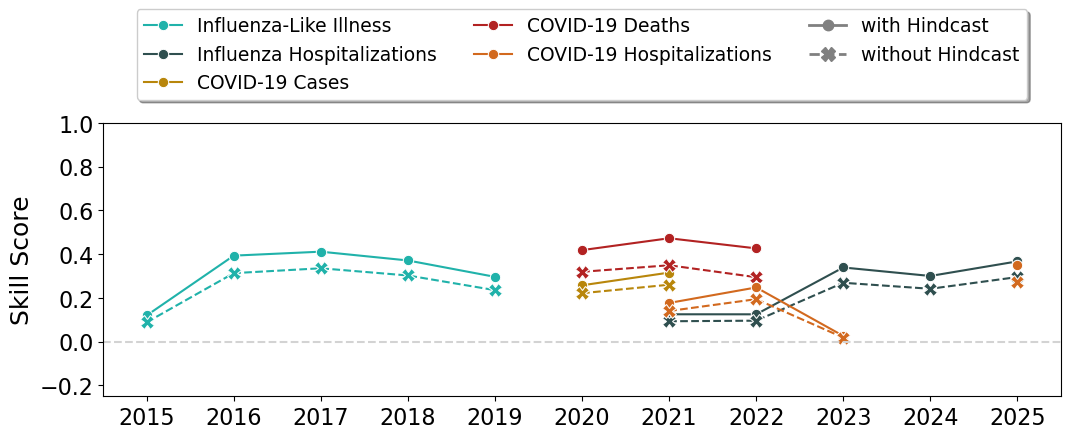

In [16]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team=='UnwghtAvg') & (ILI_LS.season!='2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble.copy()
df = df.groupby(['team','season'])['logit_wis', 'logit_wis_ets_baseline', 'logit_wis_hindcast'].mean().reset_index()

df['ss'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_ets_baseline'])
df['relwis'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (0 - df['logit_wis_ets_baseline'])

df['horizon'] = 0
df = df.sort_values(by='horizon')

line_styles = ['-', '--', '-.', ':']
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='lightseagreen',
        alpha=1,linestyle='-',marker='.',markersize=15,
        label=f'Influenza-Like Illness')
    
    sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color='lightseagreen',
        alpha=1,linestyle='--',marker='X',markersize=10)

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['Flusight-ensemble', 'FluSight-ensemble', ]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    
    df = df.groupby(['team','season'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    
    df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])
    df['relwis'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (0 - df['log_wis_ets_baseline'])
    df['horizon'] = 0
    
    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color='darkslategrey',
            alpha=1,linestyle='-',marker='.',markersize=15,
            label=f'Influenza Hospitalizations')
        
        sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color='darkslategrey',
            alpha=1,linestyle='--',marker='X',markersize=10)

    i+=1
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
    
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3)&\
                                      (~covid_WIS.location.isin(['60']))].copy()


        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]
        df = df.sort_values(by='horizon')
        df = df.groupby(['team','season',])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])
        df['relwis'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (0 - df['log_wis_ets_baseline'])

        df['horizon'] = 0
        
        
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'
            
        horizons = df['horizon'].unique()

        ax = plt.gca()
        for i, h in enumerate(horizons):
            mask = df['horizon'] == h
            sns.lineplot(data=df[mask],x='season',y=df[mask].ss,ax=ax,color=colors,
                alpha=1,linestyle='-',marker='.',markersize=15,
                label=f'{label}')
            
            sns.lineplot(data=df[mask],x='season',y=df[mask].relwis,ax=ax,color=colors,
                alpha=1,linestyle='--',marker='X',markersize=10)

        i+=1
    j+=1
    

handles, labels = plt.gca().get_legend_handles_labels() 
  
# specify order 
order = [0,1,2,3,4] 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',marker='.', markersize=15, linewidth=2, label='with Hindcast'),
    Line2D([0], [0], color='gray', linestyle='--',marker='X',markersize=10, linewidth=2, label='without Hindcast'),
]

combined_handles = [handles[i] for i in order] + style_handles
combined_labels  = [labels[i]  for i in order] + [h.get_label() for h in style_handles]


    

ax.legend(combined_handles, combined_labels,fontsize=13.5,
    loc='upper center', bbox_to_anchor=(0.5, 1.45), ncol=3, fancybox=True, shadow=True )


plt.axhline(y=0,color='lightgray',linestyle='--')

plt.ylim([-.25,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)
plt.xlabel('')

plt.tight_layout()
plt.savefig('figs/figS4-SS_hindcast_comp_trend.pdf')
plt.show()

# Fig S5 - comparison to hub-generated baseline

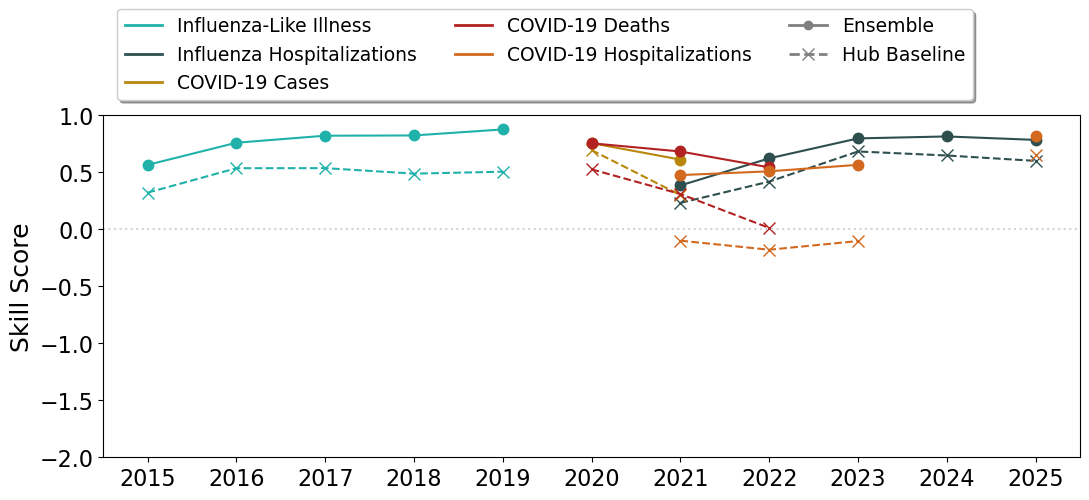

In [17]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team.isin(['Hist-Avg', 'UnwghtAvg']))]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
for team in flu_ensemble.team.unique():
    
    df = flu_ensemble[(flu_ensemble.team==team) & (flu_ensemble.season!=2014)].copy()
    df = df.groupby(['team','season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['logit_wis'] -df['logit_wis_naive']) / (df['logit_wis_hindcast']- df['logit_wis_naive'])

    vals = df.groupby(['season'])['ss'].mean()

    if team=='Hist-Avg':
        plt.plot(df.season.unique(), vals,'x-',markersize=8,color='lightseagreen',alpha=1,label='Influenza-like Illness',
            linestyle='--')
        
    else:
        plt.plot(df.season.unique(), vals,'.-',markersize=15,color='lightseagreen',alpha=1,label='Influenza-like Illness')

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['FluSight-baseline', 'Flusight-ensemble', 'FluSight-ensemble',]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    
    df = df.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] -df['log_wis_naive'] ) / (df['log_wis_hindcast'] - df['log_wis_naive'])
    vals = df.groupby(['team' ,'season'])['ss'].mean()
    
    if team in'FluSight-ensemble':
        plt.plot(df.season.unique(), vals,'.-',markersize=15,color='darkslategrey',alpha=1,label='Influenza Hospitalizations')
    elif team == 'FluSight-baseline':
        plt.plot(df.season.unique(), vals,'x-',markersize=8,color='darkslategrey',alpha=1,
                 label='Influenza Hospitalizations',linestyle='--')
    i+=1

    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-baseline', 'CovidHub-baseline', 'COVIDhub-4_week_ensemble', 'CovidHub-ensemble']

j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:

        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &\
                                      (~covid_WIS.location.isin(['60']))].copy()

        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)]

        df = df.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast'].mean().reset_index()
        df['ss'] = (df['log_wis'] -df['log_wis_naive'] ) / (df['log_wis_hindcast'] - df['log_wis_naive'])
        vals = df.groupby(['team' ,'season'])['ss'].mean()
        
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'    
            
        if team in ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']:
            plt.plot(df.season.unique(), vals,'.-',markersize=15,color=colors,alpha=1,label=label)
        elif team in ['COVIDhub-baseline', 'CovidHub-baseline']:
            plt.plot(df.season.unique(), vals,'x-',markersize=8,color=colors,alpha=1,label=label,linestyle='--')
             
        i+=1
    j+=1
    

color_handles = [
    Line2D([0], [0], color='lightseagreen',  label='Influenza-Like Illness',linewidth=2,),
    Line2D([0], [0], color='darkslategrey', label='Influenza Hospitalizations',linewidth=2,),
    Line2D([0], [0], color='darkgoldenrod', label='COVID-19 Cases',linewidth=2,),
    Line2D([0], [0], color='firebrick', label='COVID-19 Deaths',linewidth=2,),
    Line2D([0], [0], color='chocolate',  label='COVID-19 Hospitalizations',linewidth=2,),
]

style_handles = [
    Line2D([0], [0], color='gray', linestyle='-', marker='o',markersize=6,linewidth=2, label='Ensemble'),
    Line2D([0], [0], color='gray', linestyle='--', marker='x',markersize=8, linewidth=2, label='Hub Baseline'),
    ]

# Combine legends
all_handles = color_handles + style_handles

fig.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
           ncol=3, fontsize=13.5, fancybox=True, shadow=True  )  

plt.axhline(y=0,color='lightgray',linestyle=':')

plt.ylim([-2,1])

plt.xticks([ 2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])
 
plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(top=0.78)  # Make room for the legend

plt.savefig('figs/figS5-SS_hubbaseline_naive.pdf')
plt.show()

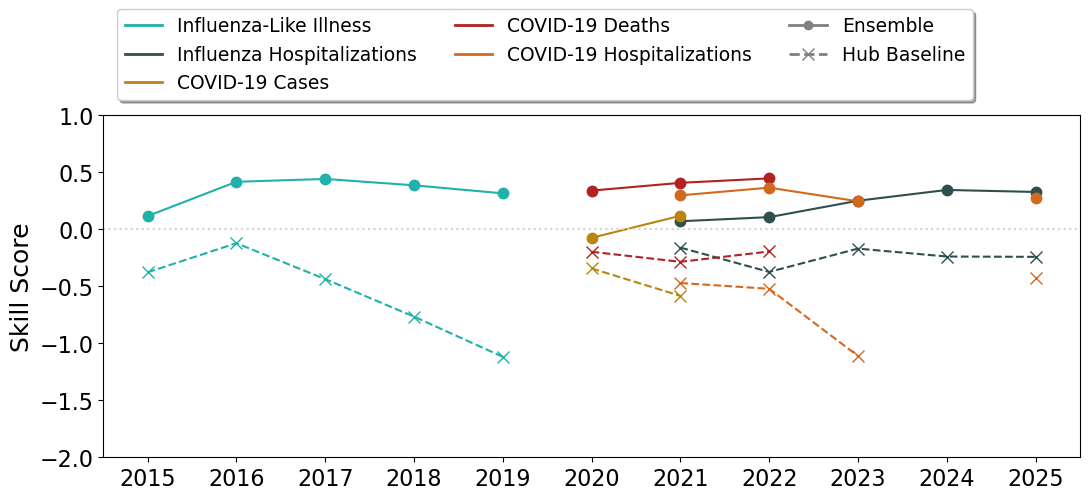

In [18]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team.isin(['Hist-Avg', 'UnwghtAvg']))]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
for team in flu_ensemble.team.unique():

    df = flu_ensemble[(flu_ensemble.team==team) & (flu_ensemble.season!=2014)].copy()
    df = df.groupby(['team','season'])['logit_wis', 'logit_wis_logit_baseline', 'logit_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['logit_wis'] - df['logit_wis_logit_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_logit_baseline'])

    vals = df.groupby(['season'])['ss'].mean()

    if team=='Hist-Avg':
        plt.plot(df.season.unique(), vals,'x-',markersize=8,color='lightseagreen',alpha=1,linestyle='--')
    else:
        plt.plot(df.season.unique(), vals,'.-',markersize=15,color='lightseagreen',alpha=1,)

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['FluSight-baseline', 'Flusight-ensemble', 'FluSight-ensemble',]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()
    
    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    df = df.groupby(['team','season'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])
    
    vals = df.groupby(['team' ,'season'])['ss'].mean()

    if team in'FluSight-ensemble':
        plt.plot(df.season.unique(), vals,'.-',markersize=15,color='darkslategrey',alpha=1,label='Influenza Hospitalizations')
    elif team == 'FluSight-baseline':
        plt.plot(df.season.unique(), vals,'x-',markersize=8,color='darkslategrey',alpha=1,linestyle='--')
      
    i+=1

covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-baseline', 'CovidHub-baseline', 'COVIDhub-4_week_ensemble', 'CovidHub-ensemble']

j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:
        
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'    
            
        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &\
                                      (~covid_WIS.location.isin(['60']))].copy()

        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)] 
        df = df.groupby(['team','season'])['log_wis', 'log_wis_lbaseline', 'log_wis_hindcast'].mean().reset_index()
    
        df['ss'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])

        vals = df.groupby(['team' ,'season'])['ss'].mean()
        
        if team in ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']:
            plt.plot(df.season.unique(), vals,'.-',markersize=15,color=colors,alpha=1,label=label)
        elif team in ['COVIDhub-baseline', 'CovidHub-baseline']:
            plt.plot(df.season.unique(), vals,'x-',markersize=8,color=colors,alpha=1,label=label,linestyle='--')
    
        i+=1
    j+=1
    

color_handles = [
    Line2D([0], [0], color='lightseagreen',  label='Influenza-Like Illness',linewidth=2,),
    Line2D([0], [0], color='darkslategrey', label='Influenza Hospitalizations',linewidth=2,),
    Line2D([0], [0], color='darkgoldenrod', label='COVID-19 Cases',linewidth=2,),
    Line2D([0], [0], color='firebrick', label='COVID-19 Deaths',linewidth=2,),
    Line2D([0], [0], color='chocolate',  label='COVID-19 Hospitalizations',linewidth=2,),
]

style_handles = [
    Line2D([0], [0], color='gray', linestyle='-', marker='o',markersize=6,linewidth=2, label='Ensemble'),
    Line2D([0], [0], color='gray', linestyle='--', marker='x',markersize=8, linewidth=2, label='Hub Baseline'),
   ]

# Combine legends
all_handles = color_handles + style_handles

fig.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
           ncol=3, fontsize=13.5, fancybox=True, shadow=True  )
  
plt.axhline(y=0,color='lightgray',linestyle=':')

plt.ylim([-2,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])
 
plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(top=0.78)  # Make room for the legend

plt.savefig('figs/figS5-SS_hubbaseline_RW.pdf')
plt.show()

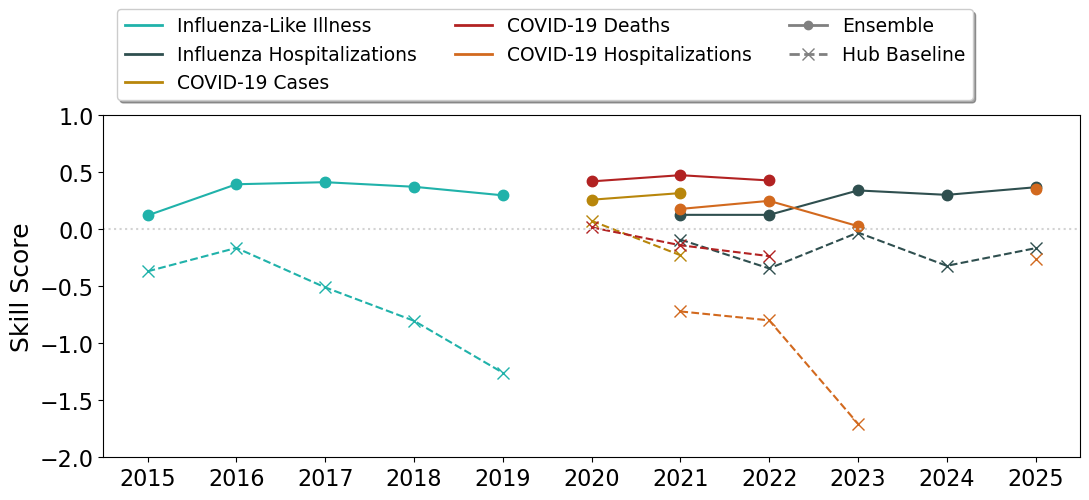

In [19]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team.isin(['Hist-Avg', 'UnwghtAvg']))]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
for team in flu_ensemble.team.unique():
 
    df = flu_ensemble[(flu_ensemble.team==team) & (flu_ensemble.season!=2014)].copy()
    df = df.groupby(['team','season'])['logit_wis', 'logit_wis_ets_baseline', 'logit_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_ets_baseline'])

    vals = df.groupby(['season'])['ss'].mean()

    if team=='Hist-Avg':
        plt.plot(df.season.unique(), vals,'x-',markersize=8,color='lightseagreen',alpha=1,linestyle='--')
    else:
        plt.plot(df.season.unique(), vals,'.-',markersize=15,color='lightseagreen',alpha=1,)

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
i=0
for team in ['FluSight-baseline', 'Flusight-ensemble', 'FluSight-ensemble',]:
    
    flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
    (flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                              (~flu_WIS.location.isin(['60','78']))].copy()

    df = flu_WIS_filtered[(flu_WIS_filtered.team==team) ]
    df = df.groupby(['team','season'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
    df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])
    
    vals = df.groupby(['team' ,'season'])['ss'].mean()

    if team in'FluSight-ensemble':
        plt.plot(df.season.unique(), vals,'.-',markersize=15,color='darkslategrey',alpha=1,label='Influenza Hospitalizations')
    elif team == 'FluSight-baseline':
        plt.plot(df.season.unique(), vals,'x-',markersize=8,color='darkslategrey',alpha=1,linestyle='--')
    
    i+=1
    
covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-baseline', 'CovidHub-baseline', 'COVIDhub-4_week_ensemble', 'CovidHub-ensemble']
  
j=1
for target in covid_WIS.outcome.unique():
    i=0
    for team in teams:
        
        if target=='hosp':
            colors = 'chocolate'
            label = 'COVID-19 Hospitalizations'
        elif target=='death':
            colors = 'firebrick'
            label='COVID-19 Deaths'
        elif target=='case':
            colors = 'darkgoldenrod'
            label='COVID-19 Cases'    
          
        covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &\
                                      (~covid_WIS.location.isin(['60']))].copy()

        df = covid_WIS_filtered[(covid_WIS_filtered.team==team) & (covid_WIS_filtered.outcome==target)] 
        df = df.groupby(['team','season'])['log_wis', 'log_wis_ets_baseline', 'log_wis_hindcast'].mean().reset_index()
        df['ss'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])

        vals = df.groupby(['team' ,'season'])['ss'].mean()
        
        if team in ['COVIDhub-4_week_ensemble', 'CovidHub-ensemble']:
            plt.plot(df.season.unique(), vals,'.-',markersize=15,color=colors,alpha=1,label=label)
        elif team in ['COVIDhub-baseline', 'CovidHub-baseline']:
            plt.plot(df.season.unique(), vals,'x-',markersize=8,color=colors,alpha=1,label=label,linestyle='--')
    
        i+=1
    j+=1
    
color_handles = [
    Line2D([0], [0], color='lightseagreen',  label='Influenza-Like Illness',linewidth=2,),
    Line2D([0], [0], color='darkslategrey', label='Influenza Hospitalizations',linewidth=2,),
    Line2D([0], [0], color='darkgoldenrod', label='COVID-19 Cases',linewidth=2,),
    Line2D([0], [0], color='firebrick', label='COVID-19 Deaths',linewidth=2,),
    Line2D([0], [0], color='chocolate',  label='COVID-19 Hospitalizations',linewidth=2,),
]

style_handles = [
    Line2D([0], [0], color='gray', linestyle='-', marker='o',markersize=6,linewidth=2, label='Ensemble'),
    Line2D([0], [0], color='gray', linestyle='--', marker='x',markersize=8, linewidth=2, label='Hub Baseline'),
   ]

# Combine legends
all_handles = color_handles + style_handles

fig.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
           ncol=3, fontsize=13.5, fancybox=True, shadow=True  )

plt.axhline(y=0,color='lightgray',linestyle=':')

plt.ylim([-2,1])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Skill Score', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(top=0.78)  # Make room for the legend

plt.savefig('figs/figS5-SS_hubbaseline_trend.pdf')
plt.show()

# Fig S6 - ensemble relative WIS

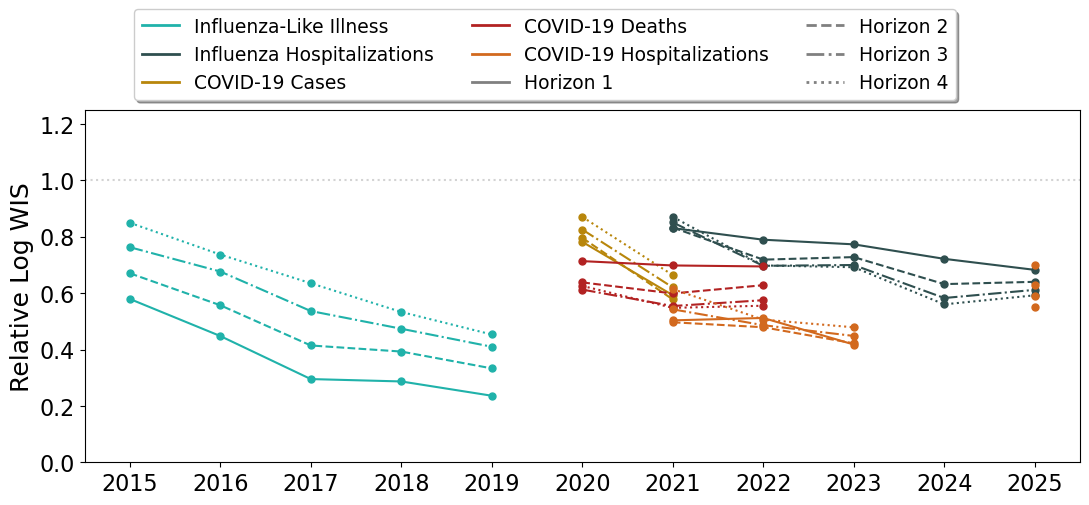

In [20]:
fig,ax = plt.subplots(1,1,figsize=(11,5))

line_styles = ['-', '--', '-.', ':']
horizons = [0,1,2,3]

ILI_LS = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ensemble = ILI_LS[ (ILI_LS.horizon<=3) & (ILI_LS.team.isin(['Hist-Avg', 'UnwghtAvg'])) & \
                     (ILI_LS.season != '2014-2015')]
flu_ensemble['season'] = flu_ensemble['season'].apply(lambda x:int(x[0:4]))
    
df = flu_ensemble[flu_ensemble.team=='UnwghtAvg'].copy()
df = df.groupby(['team','season','horizon'])['logit_wis',].mean().reset_index()

dfbase = flu_ensemble[flu_ensemble.team=='Hist-Avg'].copy()
dfbase = dfbase.groupby(['team','season','horizon'])['logit_wis',].mean().reset_index().rename(columns={'logit_wis':'logit_wis_baseline'})

df = df.merge(dfbase, on=['season','horizon'])

df['rwis'] = (df['logit_wis'] ) / ( df['logit_wis_baseline'])

vals = df.groupby(['season', 'horizon'])['rwis'].mean()

df = df.sort_values(by='horizon')
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
        
    segment_df = df[mask].set_index('season').reindex(range(df['season'].min(), df['season'].max()+1))
    
    ax.plot(segment_df.index, segment_df['rwis'], color='lightseagreen', alpha=1,
                    linestyle=line_styles[i % len(line_styles)], marker='.',markersize=10,)

flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_ensemble = flu_WIS[(flu_WIS.team.isin(['Flusight-ensemble', 'FluSight-ensemble','FluSight-baseline'])) ]
flu_WIS = flu_ensemble[flu_ensemble.horizon<=3]
flu_WIS['season'] = flu_WIS['season'].apply(lambda x:int(x[0:4]))
    
flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  # Horizon filter
(flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',  'FluSight-ensemble', 'FluSight-baseline']))&\
                          (~flu_WIS.location.isin(['60','78']))].copy()

df = flu_WIS_filtered[(flu_WIS_filtered.team=='FluSight-ensemble') ]
df = df.groupby(['team','season', 'horizon'])['log_wis', ].mean().reset_index()

dfbase = flu_WIS_filtered[(flu_WIS_filtered.team=='FluSight-baseline') ]
dfbase = dfbase.groupby(['team','season', 'horizon'])['log_wis', ].mean().reset_index().rename(columns={'log_wis':'log_wis_baseline'})

df = df.merge(dfbase, on=['season', 'horizon'])

df['rwis'] = (df['log_wis']) / ( df['log_wis_baseline'])

vals = df.groupby([ 'season', 'horizon'])['rwis'].mean()

df = df.sort_values(by='horizon')
horizons = df['horizon'].unique()

ax = plt.gca()
for i, h in enumerate(horizons):
    mask = df['horizon'] == h
    
    segment_df = df[mask].set_index('season').reindex(range(df['season'].min(), df['season'].max()+1))
    
    ax.plot(segment_df.index, segment_df['rwis'], color='darkslategrey', alpha=1,
                    linestyle=line_styles[i % len(line_styles)], marker='.',markersize=10,)


covid_WIS = pd.read_parquet('scored forecasts/COVID19_subset_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

teams = ['COVIDhub-baseline', 'CovidHub-baseline', 'COVIDhub-4_week_ensemble', 'CovidHub-ensemble']

j=1
for target in covid_WIS.outcome.unique():
    
    if target=='hosp':
        colors = 'chocolate'
        label = 'COVID-19 Hospitalizations'
    elif target=='death':
        colors = 'firebrick'
        label='COVID-19 Deaths'
    elif target=='case':
        colors = 'darkgoldenrod'
        label='COVID-19 Cases'    

    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &\
                                  (~covid_WIS.location.isin(['60']))].copy()

    df = covid_WIS_filtered[(covid_WIS_filtered.team.isin(['COVIDhub-4_week_ensemble', 'CovidHub-ensemble'])) & \
                            (covid_WIS_filtered.outcome==target)] 
    df = df.groupby(['team','season', 'horizon'])['log_wis', ].mean().reset_index()

    dfbase = covid_WIS_filtered[(covid_WIS_filtered.team.isin(['COVIDhub-baseline', 'CovidHub-baseline', ])) & \
                            (covid_WIS_filtered.outcome==target)] 
    dfbase = dfbase.groupby(['team','season', 'horizon'])['log_wis', ].mean().reset_index().rename(columns={'log_wis':'log_wis_baseline'})

    df = df.merge(dfbase, on=['season', 'horizon'])


    df['rwis'] = (df['log_wis'] ) / ( df['log_wis_baseline'])

    vals = df.groupby(['season', 'horizon'])['rwis'].mean()

    df = df.sort_values(by='horizon')
    horizons = df['horizon'].unique()

    ax = plt.gca()
    for i, h in enumerate(horizons):
        mask = df['horizon'] == h
        segment_df = df[mask].set_index('season').reindex(range(df['season'].min(), df['season'].max()+1))
    
        ax.plot(segment_df.index, segment_df['rwis'], color=colors, alpha=1,
                    linestyle=line_styles[i % len(line_styles)], marker='.',markersize=10,)
       
    j+=1
    

color_handles = [
    Line2D([0], [0], color='lightseagreen',  label='Influenza-Like Illness',linewidth=2,),
    Line2D([0], [0], color='darkslategrey', label='Influenza Hospitalizations',linewidth=2,),
    Line2D([0], [0], color='darkgoldenrod', label='COVID-19 Cases',linewidth=2,),
    Line2D([0], [0], color='firebrick', label='COVID-19 Deaths',linewidth=2,),
    Line2D([0], [0], color='chocolate',  label='COVID-19 Hospitalizations',linewidth=2,),
]

handles, labels = plt.gca().get_legend_handles_labels() 
  
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',  linewidth=2, label='Horizon 1'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Horizon 2'),
    Line2D([0], [0], color='gray', linestyle='-.', linewidth=2, label='Horizon 3'),
    Line2D([0], [0], color='gray', linestyle=':',  linewidth=2, label='Horizon 4')
]


# Combine legends
all_handles = color_handles + style_handles
fig.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=3, fontsize=13.5, fancybox=True, shadow=True  )
    
plt.axhline(y=1,color='lightgray',linestyle=':')

plt.ylim([0,1.25])

plt.xticks([2015,2016,2017,2018,2019, 2020,2021,2022,2023,2024, 2025])

plt.xticks(fontsize=16, )
plt.yticks(fontsize=16)
plt.ylabel('Relative Log WIS', fontsize=18)
plt.xlabel('', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(top=0.8)  # Make room for the legend

plt.savefig('figs/figS6-relativeWIS_hubbaseline.pdf')
plt.show()

# Fig S7 - comparison to 14 baseline models

see baseline model comparison/ folder and plot_season_mwis_single.py to generate

# Fig S8 - individual team performance

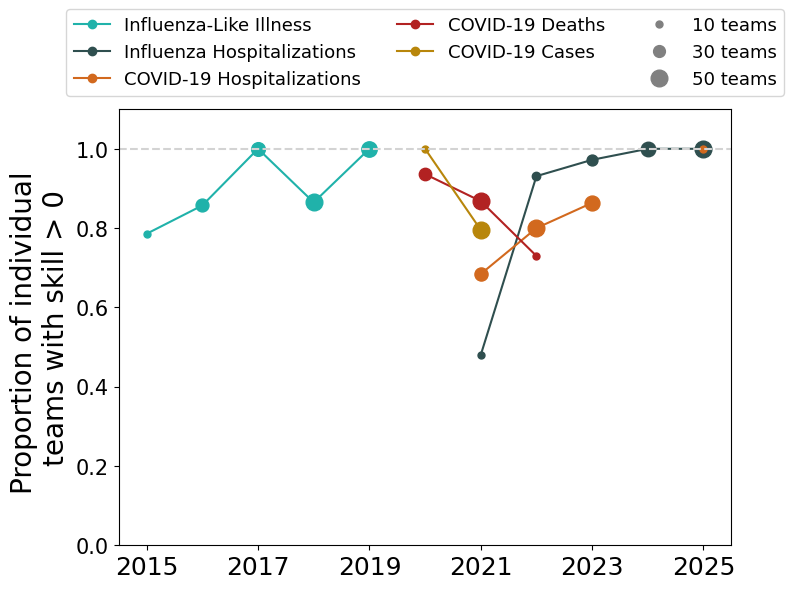

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))


def get_total_teams(raw_df, season_col='season'):
    """Count unique teams per season """
    total = raw_df.groupby(season_col)['team'].nunique().reset_index()
    total.columns = [season_col, 'total_teams']
    return total

def plot_proportion(ax, proportion, color, label):
    """
    proportion must have: season, ss_n, total_teams.
    CI is Wilson 95%; marker size scaled by total_teams within series.
    """
    proportion = proportion.sort_values('season')
    seasons = proportion['season'].values

    props = proportion['ss_n'].values.astype(float)
    n_raw = proportion['total_teams'].values

    lo = np.full(len(props), np.nan)
    hi = np.full(len(props), np.nan)
    sizes = np.full(len(props), 6.0)

    valid = ~np.isnan(props) & ~pd.isnull(n_raw)
    n_valid = n_raw[valid].astype(int)
    sizes[valid] = 10 + 14 * (n_valid - n_valid.min()) / (n_valid.max() - n_valid.min() + 1e-9)

    segments = np.split(np.arange(len(seasons)), np.where(np.isnan(props))[0])
    for seg in segments:
        seg = seg[~np.isnan(props[seg])]
        if len(seg) == 0:
            continue
        ax.plot(seasons[seg], props[seg], '-', color=color, alpha=1)
        for x, y, s in zip(seasons[seg], props[seg], sizes[seg]):
            ax.plot(x, y, '.', markersize=s, color=color)

    ax.plot([], [], '.-', markersize=12, color=color, label=label)



#  ILI 
flu_ILI = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ILI['season'] = flu_ILI['season'].apply(lambda x: int(x[0:4]))

flu_ILI_filtered = flu_ILI[
   (flu_ILI['horizon'] >= 0) & (flu_ILI['horizon'] <= 3) & (flu_ILI.season!=2014) &
    (~flu_ILI.location.isin(['60', '78'])) &
    (~flu_ILI['team'].isin(['UnwghtAvg', 'Hist-Avg']))
].copy()

df = flu_ILI_filtered.groupby(['team', 'season'])[
    'logit_wis', 'logit_wis_naive', 'logit_wis_hindcast', 'logit_wis_logit_baseline'
].mean().reset_index()
df['ss_n'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])

proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
proportion = proportion.merge(get_total_teams(flu_ILI), on='season', how='left')

plot_proportion(ax, proportion, color='lightseagreen', label='Influenza-Like Illness')


#  Influenza Hospitalizations 
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_WIS['season'] = flu_WIS['season'].apply(lambda x: int(x[0:4]))

flu_WIS_filtered = flu_WIS[
    (flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &
    (~flu_WIS.location.isin(['60', '78'])) &
    (~flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',
                             'FluSight-ensemble', 'FluSight-baseline']))
].copy()

df = flu_WIS_filtered.groupby(['team', 'season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast', 
                                                  'log_wis_lbaseline'].mean().reset_index()
df['ss_n'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])

proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
proportion = proportion.merge(get_total_teams(flu_WIS), on='season', how='left')

plot_proportion(ax, proportion, color='darkslategrey', label='Influenza Hospitalizations')


#  COVID-19 
covid_WIS = pd.read_parquet('scored forecasts/COVID19_ADM1_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

target_style = {
    'hosp':  ('chocolate',     'COVID-19 Hospitalizations'),
    'death': ('firebrick',     'COVID-19 Deaths'),
    'case':  ('darkgoldenrod', 'COVID-19 Cases'),}

for target, (colors, label) in target_style.items():
    covid_WIS_filtered = covid_WIS[
        (covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &
        (~covid_WIS.location.isin(['60'])) &
        (covid_WIS.outcome == target) &
        (~covid_WIS.log_wis.isna()) &
        (covid_WIS.log_wis != -np.inf) &
        (covid_WIS.log_wis != np.inf) &
        (~covid_WIS['team'].isin([
            'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'COVIDhub-ensemble',
            'COVIDhub-trained_ensemble', 'COVIDhub_CDC-ensemble',
            'CovidHub-baseline', 'CovidHub-ensemble', ]))].copy()

    df = covid_WIS_filtered.groupby(['team', 'season'])[
        'log_wis', 'log_wis_naive', 'log_wis_hindcast', 'log_wis_lbaseline'
    ].mean().reset_index()
    df['ss_n'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])

    proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
    
    proportion = proportion.merge(
        get_total_teams(covid_WIS[covid_WIS.outcome == target]), on='season', how='left' )

    if target == 'hosp':
        proportion = pd.concat([
            proportion,
            pd.DataFrame({'season': [2024], 'ss_n': [np.nan], 'total_teams': [np.nan]})
        ]).sort_values('season').reset_index(drop=True)

    plot_proportion(ax, proportion, color=colors, label=label)

from matplotlib.lines import Line2D

n_min = 10   
n_max = 50   

n_vals = [n_min, int((n_min + n_max) / 2), n_max]
size_vals = [10+ 14 * (n - n_min) / (n_max - n_min + 1e-9) for n in n_vals]

spacer = Line2D([0], [0], linestyle='None', marker='None', label='')
legend_elements = [
    Line2D([0], [0], marker='.', color='lightseagreen', linestyle='-', markersize=12, label='Influenza-Like Illness'),
    Line2D([0], [0], marker='.', color='darkslategrey',  linestyle='-', markersize=12, label='Influenza Hospitalizations'),
    Line2D([0], [0], marker='.', color='chocolate',      linestyle='-', markersize=12, label='COVID-19 Hospitalizations'),
    Line2D([0], [0], marker='.', color='firebrick',      linestyle='-', markersize=12, label='COVID-19 Deaths'),
    Line2D([0], [0], marker='.', color='darkgoldenrod',  linestyle='-', markersize=12, label='COVID-19 Cases'),
    spacer,
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[0], label=f'{n_vals[0]} teams'),
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[1], label=f'{n_vals[1]} teams'),
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[2], label=f'{n_vals[2]} teams'),
]

ax.legend(
    handles=legend_elements,
    fontsize=13,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=True,
)

ax.set_xticks([2015, 2017,  2019, 2021, 2023,  2025])
ax.set_ylim([0, 1.1])
ax.axhline(y=1, color='lightgray', linestyle='--')
ax.set_ylabel('Proportion of individual \nteams with skill > 0', fontsize=20)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.savefig('figs/figS8-teams_skill_proportion_naive.pdf')
plt.show()

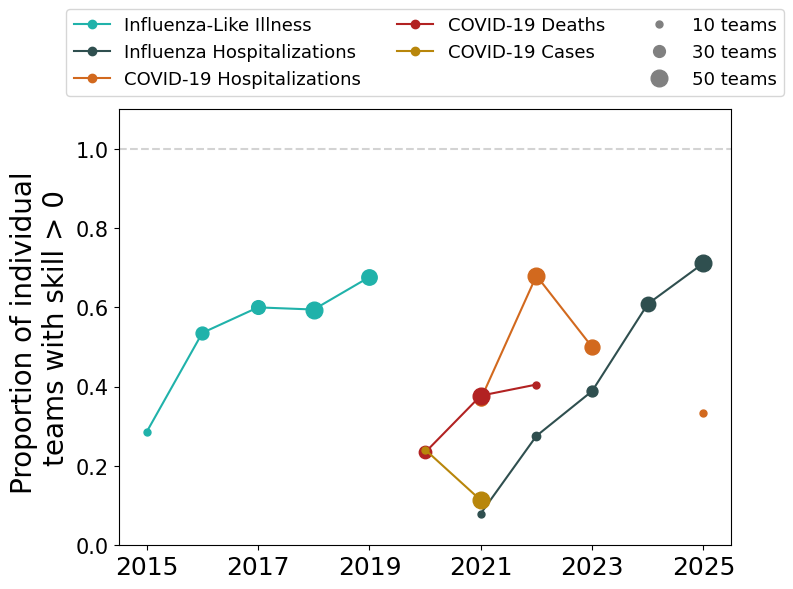

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ILI
flu_ILI = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ILI['season'] = flu_ILI['season'].apply(lambda x: int(x[0:4]))

flu_ILI_filtered = flu_ILI[
    (flu_ILI['horizon'] >= 0) & (flu_ILI['horizon'] <= 3) & (flu_ILI.season!=2014) &
    (~flu_ILI.location.isin(['60', '78'])) &
    (~flu_ILI['team'].isin(['UnwghtAvg', 'Hist-Avg']))].copy()

df = flu_ILI_filtered.groupby(['team', 'season'])[
    'logit_wis', 'logit_wis_naive', 'logit_wis_hindcast', 'logit_wis_logit_baseline'].mean().reset_index()
df['ss_n'] = (df['logit_wis'] - df['logit_wis_logit_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_logit_baseline'])

proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
proportion = proportion.merge(get_total_teams(flu_ILI), on='season', how='left')

plot_proportion(ax, proportion, color='lightseagreen', label='Influenza-Like Illness')


# Flu hospitalizations
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_WIS['season'] = flu_WIS['season'].apply(lambda x: int(x[0:4]))

flu_WIS_filtered = flu_WIS[
    (flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &
    (~flu_WIS.location.isin(['60', '78'])) &
    (~flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',
                             'FluSight-ensemble', 'FluSight-baseline']))].copy()

df = flu_WIS_filtered.groupby(['team', 'season'])[
    'log_wis', 'log_wis_naive', 'log_wis_hindcast', 'log_wis_lbaseline'
].mean().reset_index()
df['ss_n'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])

proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
proportion = proportion.merge(get_total_teams(flu_WIS), on='season', how='left')

plot_proportion(ax, proportion, color='darkslategrey', label='Influenza Hospitalizations')


# COVID-19
covid_WIS = pd.read_parquet('scored forecasts/COVID19_ADM1_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

target_style = {
    'hosp':  ('chocolate',     'COVID-19 Hospitalizations'),
    'death': ('firebrick',     'COVID-19 Deaths'),
    'case':  ('darkgoldenrod', 'COVID-19 Cases'),}

for target, (colors, label) in target_style.items():
    covid_WIS_filtered = covid_WIS[
        (covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &
        (~covid_WIS.location.isin(['60'])) &
        (covid_WIS.outcome == target) &
        (~covid_WIS.log_wis.isna()) &
        (covid_WIS.log_wis != -np.inf) &
        (covid_WIS.log_wis != np.inf) &
        (~covid_WIS['team'].isin([
            'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'COVIDhub-ensemble',
            'COVIDhub-trained_ensemble', 'COVIDhub_CDC-ensemble',
            'CovidHub-baseline', 'CovidHub-ensemble',  ])) ].copy()

    df = covid_WIS_filtered.groupby(['team', 'season'])[
        'log_wis', 'log_wis_naive', 'log_wis_hindcast', 'log_wis_lbaseline'].mean().reset_index()
    df['ss_n'] = (df['log_wis'] - df['log_wis_lbaseline']) / (df['log_wis_hindcast'] - df['log_wis_lbaseline'])

    proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
    proportion = proportion.merge(
        get_total_teams(covid_WIS[covid_WIS.outcome == target]), on='season', how='left')

    if target == 'hosp':
        proportion = pd.concat([
            proportion,
            pd.DataFrame({'season': [2024], 'ss_n': [np.nan], 'total_teams': [np.nan]})
        ]).sort_values('season').reset_index(drop=True)

    plot_proportion(ax, proportion, color=colors, label=label)

from matplotlib.lines import Line2D

n_min = 10  
n_max = 50  

n_vals = [n_min, int((n_min + n_max) / 2), n_max]
size_vals = [10 + 14 * (n - n_min) / (n_max - n_min + 1e-9) for n in n_vals]

spacer = Line2D([0], [0], linestyle='None', marker='None', label='')
legend_elements = [
    Line2D([0], [0], marker='.', color='lightseagreen', linestyle='-', markersize=12, label='Influenza-Like Illness'),
    Line2D([0], [0], marker='.', color='darkslategrey',  linestyle='-', markersize=12, label='Influenza Hospitalizations'),
    Line2D([0], [0], marker='.', color='chocolate',      linestyle='-', markersize=12, label='COVID-19 Hospitalizations'),
    Line2D([0], [0], marker='.', color='firebrick',      linestyle='-', markersize=12, label='COVID-19 Deaths'),
    Line2D([0], [0], marker='.', color='darkgoldenrod',  linestyle='-', markersize=12, label='COVID-19 Cases'),
    spacer,
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[0], label=f'{n_vals[0]} teams'),
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[1], label=f'{n_vals[1]} teams'),
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[2], label=f'{n_vals[2]} teams'),
]

ax.legend(
    handles=legend_elements,
    fontsize=13,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=True,
)

ax.set_xticks([2015, 2017,  2019, 2021, 2023,  2025])
ax.set_ylim([0, 1.1])
ax.axhline(y=1, color='lightgray', linestyle='--')
ax.set_ylabel('Proportion of individual \nteams with skill > 0', fontsize=20)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.savefig('figs/figS8-teams_skill_proportion_RW.pdf')
plt.show()

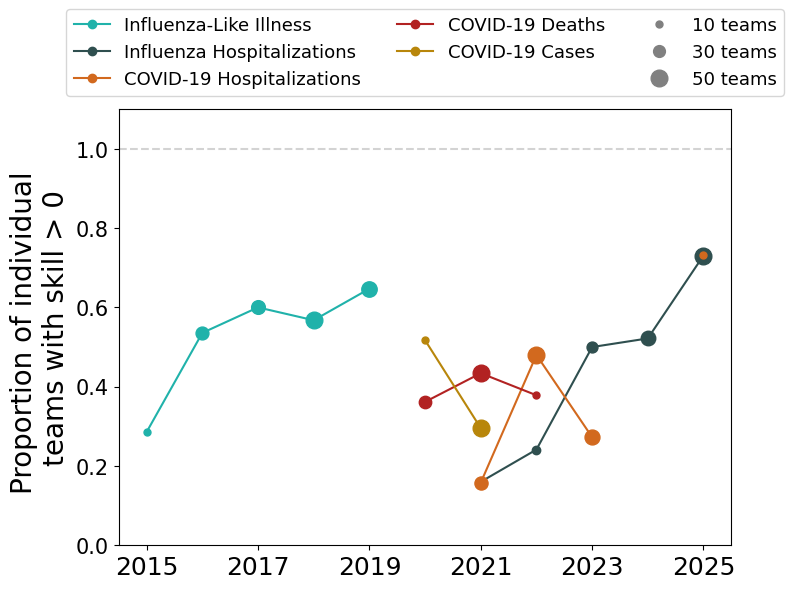

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ILI
flu_ILI = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')
flu_ILI['season'] = flu_ILI['season'].apply(lambda x: int(x[0:4]))

flu_ILI_filtered = flu_ILI[
    (flu_ILI['horizon'] >= 0) & (flu_ILI['horizon'] <= 3) & (flu_ILI.season!=2014) &
    (~flu_ILI.location.isin(['60', '78'])) &
    (~flu_ILI['team'].isin(['UnwghtAvg', 'Hist-Avg']))].copy()

df = flu_ILI_filtered.groupby(['team', 'season'])[
    'logit_wis', 'logit_wis_naive', 'logit_wis_hindcast', 'logit_wis_ets_baseline'].mean().reset_index()
df['ss_n'] = (df['logit_wis'] - df['logit_wis_ets_baseline']) / (df['logit_wis_hindcast'] - df['logit_wis_ets_baseline'])

proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
proportion = proportion.merge(get_total_teams(flu_ILI), on='season', how='left')

plot_proportion(ax, proportion, color='lightseagreen', label='Influenza-Like Illness')


# Flu hospitalizations
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_WIS['season'] = flu_WIS['season'].apply(lambda x: int(x[0:4]))

flu_WIS_filtered = flu_WIS[
    (flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &
    (~flu_WIS.location.isin(['60', '78'])) &
    (~flu_WIS['team'].isin(['Flusight-ensemble', 'Flusight-baseline',
                             'FluSight-ensemble', 'FluSight-baseline']))].copy()

df = flu_WIS_filtered.groupby(['team', 'season'])[
    'log_wis', 'log_wis_naive', 'log_wis_hindcast', 'log_wis_ets_baseline'].mean().reset_index()
df['ss_n'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])

proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
proportion = proportion.merge(get_total_teams(flu_WIS), on='season', how='left')

plot_proportion(ax, proportion, color='darkslategrey', label='Influenza Hospitalizations')


# COVID-19
covid_WIS = pd.read_parquet('scored forecasts/COVID19_ADM1_combined_WIS.parquet')
covid_WIS['season'] = covid_WIS['season'].astype(int)

target_style = {
    'hosp':  ('chocolate',     'COVID-19 Hospitalizations'),
    'death': ('firebrick',     'COVID-19 Deaths'),
    'case':  ('darkgoldenrod', 'COVID-19 Cases'),}

for target, (colors, label) in target_style.items():
    covid_WIS_filtered = covid_WIS[
        (covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &
        (~covid_WIS.location.isin(['60'])) &
        (covid_WIS.outcome == target) &
        (~covid_WIS.log_wis.isna()) &
        (covid_WIS.log_wis != -np.inf) &
        (covid_WIS.log_wis != np.inf) &
        (~covid_WIS['team'].isin([
            'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'COVIDhub-ensemble',
            'COVIDhub-trained_ensemble', 'COVIDhub_CDC-ensemble',
            'CovidHub-baseline', 'CovidHub-ensemble',   ])) ].copy()

    df = covid_WIS_filtered.groupby(['team', 'season'])[
        'log_wis', 'log_wis_naive', 'log_wis_hindcast', 'log_wis_ets_baseline' ].mean().reset_index()
    df['ss_n'] = (df['log_wis'] - df['log_wis_ets_baseline']) / (df['log_wis_hindcast'] - df['log_wis_ets_baseline'])

    proportion = df.groupby('season')['ss_n'].apply(lambda x: (x > 0).mean()).reset_index()
    proportion = proportion.merge(
        get_total_teams(covid_WIS[covid_WIS.outcome == target]), on='season', how='left' )

    if target == 'hosp':
        proportion = pd.concat([
            proportion,
            pd.DataFrame({'season': [2024], 'ss_n': [np.nan], 'total_teams': [np.nan]})
        ]).sort_values('season').reset_index(drop=True)

    plot_proportion(ax, proportion, color=colors, label=label)

from matplotlib.lines import Line2D

n_min = 10  
n_max = 50   

n_vals = [n_min, int((n_min + n_max) / 2), n_max]
size_vals = [10 + 14 * (n - n_min) / (n_max - n_min + 1e-9) for n in n_vals]

spacer = Line2D([0], [0], linestyle='None', marker='None', label='')
legend_elements = [
    Line2D([0], [0], marker='.', color='lightseagreen', linestyle='-', markersize=12, label='Influenza-Like Illness'),
    Line2D([0], [0], marker='.', color='darkslategrey',  linestyle='-', markersize=12, label='Influenza Hospitalizations'),
    Line2D([0], [0], marker='.', color='chocolate',      linestyle='-', markersize=12, label='COVID-19 Hospitalizations'),
    Line2D([0], [0], marker='.', color='firebrick',      linestyle='-', markersize=12, label='COVID-19 Deaths'),
    Line2D([0], [0], marker='.', color='darkgoldenrod',  linestyle='-', markersize=12, label='COVID-19 Cases'),
    spacer,
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[0], label=f'{n_vals[0]} teams'),
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[1], label=f'{n_vals[1]} teams'),
    Line2D([0], [0], marker='.', color='gray', linestyle='None', markersize=size_vals[2], label=f'{n_vals[2]} teams'),
]

ax.legend(
    handles=legend_elements,
    fontsize=13,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=True,
)

ax.set_xticks([2015, 2017,  2019, 2021, 2023,  2025])
ax.set_ylim([0, 1.1])
ax.axhline(y=1, color='lightgray', linestyle='--')
ax.set_ylabel('Proportion of individual \nteams with skill > 0', fontsize=20)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.savefig('figs/figS8-teams_skill_proporiton_trend.pdf')
plt.show()

In [24]:
#compute ensemble skill score and number of contributing teams per disease outcome and season

flu_ILI = pd.read_parquet('scored forecasts/flusight_ILI_combined_WIS_all.parquet')

flu_ILI_filtered = flu_ILI[(flu_ILI['horizon'] >= 0) & (flu_ILI['horizon'] <= 3) & \
                           (~flu_ILI.location.isin(['60','78']))& (flu_ILI.season!='2014-2015') &\
                          (flu_ILI['team'].isin(['UnwghtAvg',]))].copy()

df = flu_ILI_filtered.groupby(['team','season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast','logit_wis_logit_baseline'].mean().reset_index()
df['ss_n'] = (df['logit_wis'] - df['logit_wis_naive']) / (df['logit_wis_hindcast'] - df['logit_wis_naive'])

flu_ILI_filtered = flu_ILI[(flu_ILI['horizon'] >= 0) & (flu_ILI['horizon'] <= 3) &\
                        (~flu_ILI.location.isin(['60','78'])) & (flu_ILI.season!='2014-2015') &\
                          (flu_ILI['team'].isin(['UnwghtAvg', ]))].copy()

dflb = flu_ILI_filtered.groupby(['team','season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast','logit_wis_logit_baseline'].mean().reset_index()

dflb['ss_lb'] = (dflb['logit_wis'] - dflb['logit_wis_logit_baseline']) / (dflb['logit_wis_hindcast'] - dflb['logit_wis_logit_baseline'])

flu_ILI_filtered = flu_ILI[(flu_ILI['horizon'] >= 0) & (flu_ILI['horizon'] <= 3) &\
                        (~flu_ILI.location.isin(['60','78'])) & (flu_ILI.season!='2014-2015') &\
                          (flu_ILI['team'].isin(['UnwghtAvg', ]))].copy()

dfets = flu_ILI_filtered.groupby(['team','season'])['logit_wis', 'logit_wis_naive', 'logit_wis_hindcast','logit_wis_ets_baseline'].mean().reset_index()
dfets['ss_ets'] = (dfets['logit_wis'] - dfets['logit_wis_ets_baseline']) / (dfets['logit_wis_hindcast'] - dfets['logit_wis_ets_baseline'])

df = df[['team', 'season', 'ss_n']]
dflb = dflb[['team', 'season', 'ss_lb']]
dfets = dfets[['team', 'season', 'ss_ets']]

df = df.merge(dflb)
df = df.merge(dfets)

first_season = flu_ILI.groupby('team')['season'].min().reset_index()
first_season.columns = ['team', 'first_season']

# Count total teams per season 
total_per_season = flu_ILI.groupby('season')['team'].nunique().reset_index()
total_per_season.columns = ['season', 'total_teams']

first_timers_per_season = first_season.groupby('first_season')['team'].nunique().reset_index()
first_timers_per_season.columns = ['season', 'first_time_teams']

# Merge and calculate proportion
result = total_per_season.merge(first_timers_per_season, on='season', how='left')
result['first_time_teams'] = result['first_time_teams'].fillna(0).astype(int)
result['proportion_first_time'] = result['first_time_teams'] / result['total_teams']

df = df.merge(result)
dfprop_ILI = df.copy()

dfprop_ILI['season'] = dfprop_ILI['season'].apply(lambda x: int(x[0:4]))


In [25]:
flu_WIS = pd.read_parquet('scored forecasts/FluSight-hosp_combined_WIS.parquet')
flu_WIS_filtered = flu_WIS[(flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  (~flu_WIS.location.isin(['60','78'])) &\
                          (flu_WIS['team'].isin(['Flusight-ensemble',  'FluSight-ensemble', ]))].copy()

df = flu_WIS_filtered.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast','log_wis_lbaseline'].mean().reset_index()

df['ss_n'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])

flu_WIS_filtered = flu_WIS[ (flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  (~flu_WIS.location.isin(['60','78'])) &\
                          (flu_WIS['team'].isin(['Flusight-ensemble',  'FluSight-ensemble', ]))].copy()

dflb = flu_WIS_filtered.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast','log_wis_lbaseline'].mean().reset_index()
dflb['ss_lb'] = (dflb['log_wis'] - dflb['log_wis_lbaseline']) / (dflb['log_wis_hindcast'] - dflb['log_wis_lbaseline'])


flu_WIS_filtered = flu_WIS[ (flu_WIS['horizon'] >= 0) & (flu_WIS['horizon'] <= 3) &  (~flu_WIS.location.isin(['60','78'])) &\
                          (flu_WIS['team'].isin(['Flusight-ensemble',  'FluSight-ensemble', ]))].copy()
dfets = flu_WIS_filtered.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast','log_wis_ets_baseline'].mean().reset_index()
dfets['ss_ets'] = (dfets['log_wis'] - dfets['log_wis_ets_baseline']) / (dfets['log_wis_hindcast'] - dfets['log_wis_ets_baseline'])

df = df[['team', 'season', 'ss_n']]
dflb = dflb[['team', 'season', 'ss_lb']]
dfets = dfets[['team', 'season', 'ss_ets']]

df = df.merge(dflb)
df = df.merge(dfets)

first_season = flu_WIS.groupby('team')['season'].min().reset_index()
first_season.columns = ['team', 'first_season']

# Count total teams per season 
total_per_season = flu_WIS.groupby('season')['team'].nunique().reset_index()
total_per_season.columns = ['season', 'total_teams']

first_timers_per_season = first_season.groupby('first_season')['team'].nunique().reset_index()
first_timers_per_season.columns = ['season', 'first_time_teams']

# Merge and calculate proportion
result = total_per_season.merge(first_timers_per_season, on='season', how='left')
result['first_time_teams'] = result['first_time_teams'].fillna(0).astype(int)
result['proportion_first_time'] = result['first_time_teams'] / result['total_teams']

df = df.merge(result)
dfprop_fluhosp = df.copy()

dfprop_fluhosp['season'] = dfprop_fluhosp['season'].apply(lambda x: int(x[0:4]))

In [26]:
dfprop = {}

for target in ['case', 'death', 'hosp']:

    covid_WIS = pd.read_parquet('scored forecasts/COVID19_ADM1_combined_WIS.parquet')

    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &  (~covid_WIS.location.isin(['60'])) &\
        (covid_WIS.outcome==target) & (~covid_WIS.log_wis.isna()) & (covid_WIS.log_wis!=-np.inf) &\
        (covid_WIS.log_wis!=np.inf) &  
        (covid_WIS['team'].isin(['COVIDhub-4_week_ensemble','CovidHub-ensemble',]))].copy()

    df = covid_WIS_filtered.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast','log_wis_lbaseline'].mean().reset_index()

    df['ss_n'] = (df['log_wis'] - df['log_wis_naive']) / (df['log_wis_hindcast'] - df['log_wis_naive'])

    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &  (~covid_WIS.location.isin(['60'])) &\
        (covid_WIS.outcome==target) & (~covid_WIS.log_wis.isna()) & (covid_WIS_filtered.log_wis!=-np.inf) &\
                           (covid_WIS_filtered.log_wis!=np.inf) &
        (covid_WIS['team'].isin(['COVIDhub-4_week_ensemble','CovidHub-ensemble',]))].copy()

    dflb = covid_WIS_filtered.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast','log_wis_lbaseline'].mean().reset_index()
    dflb['ss_lb'] = (dflb['log_wis'] - dflb['log_wis_lbaseline']) / (dflb['log_wis_hindcast'] - dflb['log_wis_lbaseline'])


    covid_WIS_filtered = covid_WIS[(covid_WIS['horizon'] >= 0) & (covid_WIS['horizon'] <= 3) &  (~covid_WIS.location.isin(['60'])) &\
        (covid_WIS.outcome==target) & (~covid_WIS.log_wis.isna()) & (covid_WIS_filtered.log_wis!=-np.inf) &\
                           (covid_WIS_filtered.log_wis!=np.inf) &
        (covid_WIS['team'].isin(['COVIDhub-4_week_ensemble','CovidHub-ensemble',]))].copy()

    dfets = covid_WIS_filtered.groupby(['team','season'])['log_wis', 'log_wis_naive', 'log_wis_hindcast','log_wis_ets_baseline'].mean().reset_index()
    dfets['ss_ets'] = (dfets['log_wis'] - dfets['log_wis_ets_baseline']) / (dfets['log_wis_hindcast'] - dfets['log_wis_ets_baseline'])

    df = df[['team', 'season', 'ss_n']]
    dflb = dflb[['team', 'season', 'ss_lb']]
    dfets = dfets[['team', 'season', 'ss_ets']]

    df = df.merge(dflb)
    df = df.merge(dfets)

    first_season = covid_WIS[covid_WIS.outcome==target].groupby('team')['season'].min().reset_index()
    first_season.columns = ['team', 'first_season']

    # Count total teams per season 
    total_per_season = covid_WIS[covid_WIS.outcome==target].groupby('season')['team'].nunique().reset_index()
    total_per_season.columns = ['season', 'total_teams']

    first_timers_per_season = first_season.groupby('first_season')['team'].nunique().reset_index()
    first_timers_per_season.columns = ['season', 'first_time_teams']

    # Merge and calculate proportion
    result = total_per_season.merge(first_timers_per_season, on='season', how='left')
    result['first_time_teams'] = result['first_time_teams'].fillna(0).astype(int)
    result['proportion_first_time'] = result['first_time_teams'] / result['total_teams']

    df = df.merge(result)
    df['season'] = df['season'].astype(int)

    dfprop[target] = df.copy()
    
dfprop_case = dfprop['case']
dfprop_death = dfprop['death']
dfprop_hosp = dfprop['hosp']

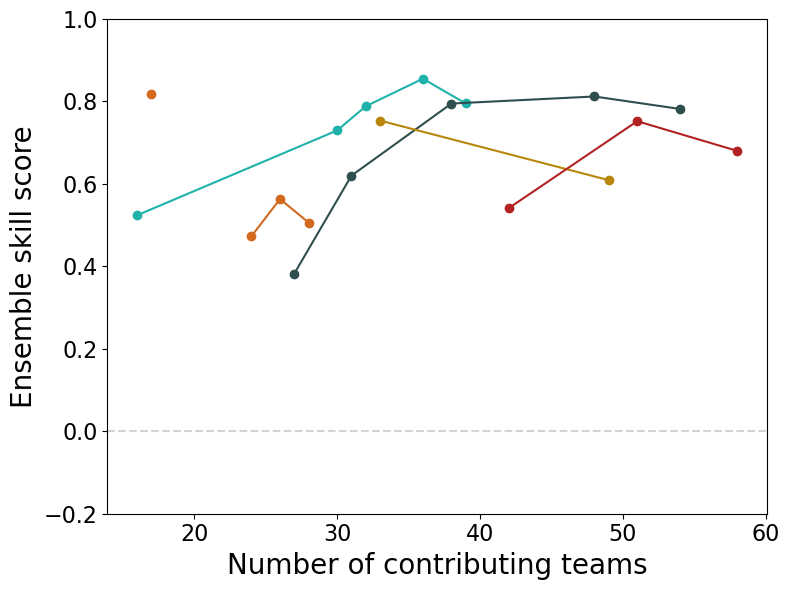

In [27]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

dfprop_ILI = dfprop_ILI.sort_values(by='total_teams')
dfprop_fluhosp = dfprop_fluhosp.sort_values(by='total_teams')
dfprop_case = dfprop_case.sort_values(by='total_teams')
dfprop_death = dfprop_death.sort_values(by='total_teams')
dfprop_hosp = dfprop_hosp.sort_values(by='total_teams')

plt.plot(dfprop_ILI.total_teams, dfprop_ILI.ss_n,'.-', color='lightseagreen',markersize=12)
plt.plot(dfprop_fluhosp.total_teams, dfprop_fluhosp.ss_n,'.-', color='darkslategrey',markersize=12)
plt.plot(dfprop_case.total_teams, dfprop_case.ss_n,'.-', color='darkgoldenrod',markersize=12)
plt.plot(dfprop_death.total_teams, dfprop_death.ss_n,'.-', color='firebrick',markersize=12)


plt.plot(dfprop_hosp[dfprop_hosp.season!=2025].total_teams, dfprop_hosp[dfprop_hosp.season!=2025].ss_n,'.-', 
         color='chocolate',markersize=12)

plt.plot(dfprop_hosp[dfprop_hosp.season==2025].total_teams, dfprop_hosp[dfprop_hosp.season==2025].ss_n,'.-', 
         color='chocolate',markersize=12)


plt.xlabel('Number of contributing teams', fontsize=20)
plt.ylabel('Ensemble skill score', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.ylim([-0.2, 1.0])
ax.axhline(y=0, color='lightgray', linestyle='--')

plt.tight_layout()
plt.savefig('figs/figS8-teams_skillscore_corr_naive.pdf')


plt.show()

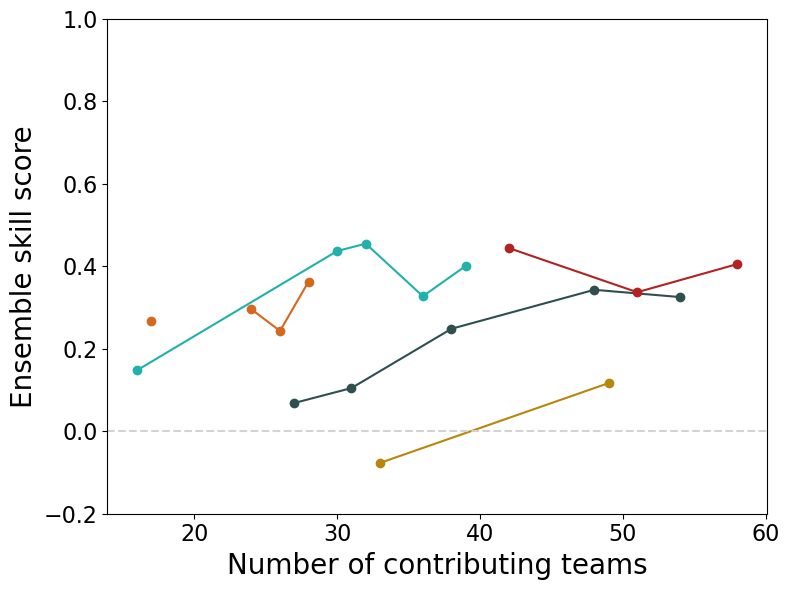

In [28]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

dfprop_ILI = dfprop_ILI.sort_values(by='total_teams')
dfprop_fluhosp = dfprop_fluhosp.sort_values(by='total_teams')
dfprop_case = dfprop_case.sort_values(by='total_teams')
dfprop_death = dfprop_death.sort_values(by='total_teams')
dfprop_hosp = dfprop_hosp.sort_values(by='total_teams')

plt.plot(dfprop_ILI.total_teams, dfprop_ILI.ss_lb,'.-', color='lightseagreen',markersize=12)
plt.plot(dfprop_fluhosp.total_teams, dfprop_fluhosp.ss_lb,'.-', color='darkslategrey',markersize=12)
plt.plot(dfprop_case.total_teams, dfprop_case.ss_lb,'.-', color='darkgoldenrod',markersize=12)
plt.plot(dfprop_death.total_teams, dfprop_death.ss_lb,'.-', color='firebrick',markersize=12)


plt.plot(dfprop_hosp[dfprop_hosp.season!=2025].total_teams, dfprop_hosp[dfprop_hosp.season!=2025].ss_lb,'.-', 
         color='chocolate',markersize=12)

plt.plot(dfprop_hosp[dfprop_hosp.season==2025].total_teams, dfprop_hosp[dfprop_hosp.season==2025].ss_lb,'.-', 
         color='chocolate',markersize=12)


plt.xlabel('Number of contributing teams', fontsize=20)
plt.ylabel('Ensemble skill score', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.ylim([-0.2, 1.0])
ax.axhline(y=0, color='lightgray', linestyle='--')

plt.tight_layout()
plt.savefig('figs/figS8-teams_skillscore_corr_RW.pdf')

plt.show()

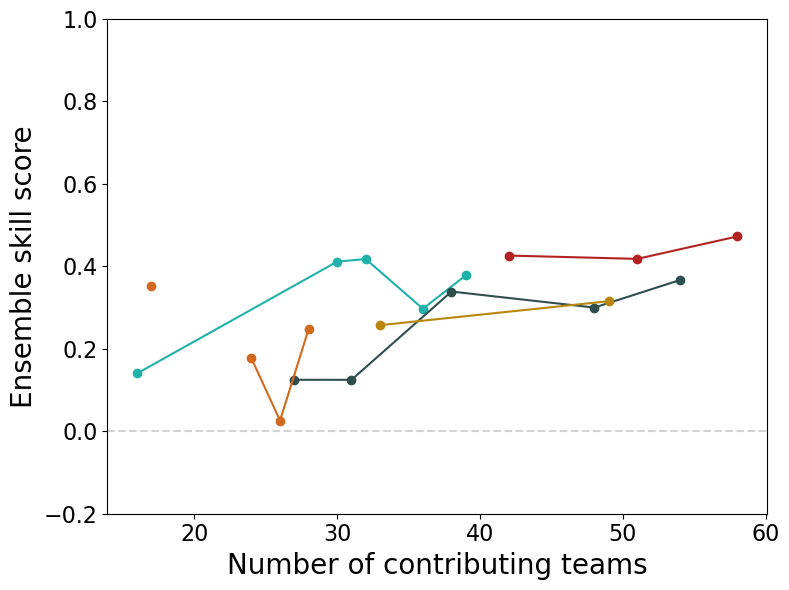

In [29]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

dfprop_ILI = dfprop_ILI.sort_values(by='total_teams')
dfprop_fluhosp = dfprop_fluhosp.sort_values(by='total_teams')
dfprop_case = dfprop_case.sort_values(by='total_teams')
dfprop_death = dfprop_death.sort_values(by='total_teams')
dfprop_hosp = dfprop_hosp.sort_values(by='total_teams')

plt.plot(dfprop_ILI.total_teams, dfprop_ILI.ss_ets,'.-', color='lightseagreen',markersize=12)
plt.plot(dfprop_fluhosp.total_teams, dfprop_fluhosp.ss_ets,'.-', color='darkslategrey',markersize=12)
plt.plot(dfprop_case.total_teams, dfprop_case.ss_ets,'.-', color='darkgoldenrod',markersize=12)
plt.plot(dfprop_death.total_teams, dfprop_death.ss_ets,'.-', color='firebrick',markersize=12)


plt.plot(dfprop_hosp[dfprop_hosp.season!=2025].total_teams, dfprop_hosp[dfprop_hosp.season!=2025].ss_ets,'.-', 
         color='chocolate',markersize=12)

plt.plot(dfprop_hosp[dfprop_hosp.season==2025].total_teams, dfprop_hosp[dfprop_hosp.season==2025].ss_ets,'.-', 
         color='chocolate',markersize=12)


plt.xlabel('Number of contributing teams', fontsize=20)
plt.ylabel('Ensemble skill score', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.ylim([-0.2, 1.0])
ax.axhline(y=0, color='lightgray', linestyle='--')

plt.tight_layout()
plt.savefig('figs/figS8-teams_skillscore_corr_trend.pdf')

plt.show()